# Sleep Classification Notebook - CFS Training/Testing 

In [22]:
%matplotlib inline

## Import packages
import glob
from natsort import natsorted
from sklearn.impute import SimpleImputer, KNNImputer
from collections import defaultdict
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_curve
from sklearn.metrics import matthews_corrcoef, auc, roc_curve, roc_auc_score, f1_score
from sklearn.model_selection import GroupShuffleSplit, cross_val_score, cross_val_predict
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import xgboost
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.feature_selection import f_classif, RFECV
from scipy import interp
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from lightgbm import LGBMClassifier
from itertools import cycle
import pandas as pd
#import pingouin as pg
import seaborn as sns
import yasa
sns.set(font_scale=1.2)
from os import chdir as cd
from os import listdir
from openTSNE import TSNE
import shap
cd('/media/administrator/data/cfs/pre_proc')

# find feature files
fls = sorted(listdir())
files = list(set([f.split('_')[0] for f in fls]))

# save path for feature importance
feat_path = '/media/administrator/data/cfs/feature_analysis/'

# model save path
save_path = '/media/administrator/data/cfs/models/'

## Additional functions

In [20]:
def preprocess_classification(files, use_ecg=True, kind='pandas'):
    if kind == 'numpy':
        allArrays = []
        stageArrays = []
        partArrays = []
        for idx, fname in enumerate(files):
            # import data arrays of features
            datArray = pickle.load(open(fname + "_allArrays_numpy.p", "rb"))
            print(idx, fname, datArray.shape.max(), 'epochs')
                
            # import data array of class labels (hypnograms )
            stageArray = pickle.load(open(fname + "_stageArrays.p", "rb"))
                
            # append all feature arrays
            allArrays.append(datArray)
            stageArrays.append(stageArray)
            partArrays.append([fname.split('-')[-1]]*len(stageArray))
        
        # combine feature, subject, and stage info   
        df = np.concatenate(allArrays)
        stages = np.concatenate(stageArrays)
        parts = np.concatenate(partArrays)
        
        return df, stages, parts
        
    elif kind =='pandas':
        allArrays = []
        for idx, fname in enumerate(files):
            # import data arrays of features
            datArray = pickle.load(open(fname + "_allArrays_df.p", "rb"))
            print(idx, fname, datArray.epoch.max(), 'epochs')
            
            # import data array of class labels (hypnograms )
            stageArray = pickle.load(open(fname + "_stageArrays.p", "rb"))
        
            # add stage label to df
            datArray['stage'] = np.ones(len(datArray))*np.nan
            for ch, df_idx in datArray.groupby(['chan']):
                datArray.loc[df_idx.index, 'stage'] = stageArray
            # also add str label 
            datArray['stage_lab'] = datArray['stage'].replace({0:'W', 1:'N1', 2: 'N2',
                                                               3: 'N3', 4: 'REM'})
            
            # import ecg features 
            if use_ecg:
                hrvArray = pickle.load(open(fname + "_allArrays_hrv_df.p", "rb"))
                print(idx, fname, hrvArray.epoch.max(), 'ecg epochs')
                hrvArray['stage'] = datArray['stage']
                hrvArray['stage_lab'] = datArray['stage_lab']
                # append all feature arrays
                allArrays.append([datArray.reset_index(drop=True), 
                                  hrvArray.reset_index(drop=True)])
                
            else:
                # append all feature arrays
                allArrays.append(datArray.reset_index(drop=True))
            
        if use_ecg:
            # combine feature, subject, and stage info   
            df_eeg = pd.concat([allArrays[i][0] for i in range(len(allArrays))])
            # drop mastoids
            df_eeg = df_eeg.set_index('chan').drop(index=['M1','M2']).reset_index()
            
            # combine feature, subject, and stage info   
            df_ecg = pd.concat([allArrays[i][1] for i in range(len(allArrays))])
            # drop columns with too many nans 
            null_counts = df_ecg.isnull().sum()
            null_percentages = null_counts / len(df_ecg)
            columns_to_drop = null_percentages[null_percentages > .10].index.tolist()
            # drop the columns
            df_ecg.drop(columns_to_drop, axis=1, inplace=True)
            
            return df_eeg, df_ecg
        
        else:
            # combine feature, subject, and stage info   
            df = pd.concat(allArrays)
            # drop mastoids
            df = df.set_index('chan').drop(index=['M1','M2']).reset_index()
 
            # # convert to np array
            # data_all = []
            # for (sub, ch, stage), df_ in df.groupby(['subject','chan','stage']):
            #     print(sub, ch, stage)
            #     data_all.append(np.expand_dims(df_[df_.columns[1:-4]].to_numpy(),1))
            #     print(len(df_))
                
            # dfs = np.concatenate(data_all, axis=1)
            # nepochs, nchans, nfeats = np.shape(dfs)
            # data_all = dfs.reshape(nepochs, nchans*nfeats, order='F')
        
        return df
    
def train_test_feature_split(df, df_ecg=None, kind='pandas', pca=False, use_smote=False):
    # Define training / testing
    groups = df['subject']

    #Split the data into training and testing sets using GroupShuffleSplit:
    gss = GroupShuffleSplit(n_splits=100, train_size=0.8, random_state=42)   
    for train_idx, test_idx in gss.split(df, groups=groups):
        # perform split
        train_data = df.iloc[train_idx]
        test_data = df.iloc[test_idx]
        #print("GROUP TRAIN:", train_data.subject.unique(),\
        #      "GROUP TEST:", test_data.subject.unique())
        if df_ecg is not None:
            ecg_train = df_ecg[df_ecg.subject.isin(train_data.subject.unique())]
            ecg_test = df_ecg[df_ecg.subject.isin(test_data.subject.unique())]

    # assign label to training/test sets in df
    df.loc[train_idx, "set"] = "training"
    df.loc[test_idx, "set"] = "testing"
        
    if kind=='pandas':
        return df
    
    elif kind=='numpy':   
        unique_chans = df.chan.unique()
        # X_train = df.set_index(['chan','set']).loc[(['C3','C4','EOG'],['training']),:][df.columns[5:-4]].to_numpy()    
        # X_test = df.set_index(['chan','set']).loc[(['C3','C4','EOG'],['testing']),:][df.columns[5:-4]].to_numpy() 
        X_train = df.set_index(['chan', 'set', 'subject','epoch']).loc[(unique_chans, ['training']), 
                                                                       df.columns[2:-4]].unstack(level='chan').to_numpy()
        X_test = df.set_index(['chan', 'set', 'subject','epoch']).loc[(unique_chans, ['testing']), 
                                                                       df.columns[2:-4]].unstack(level='chan').to_numpy()
        y_train = df.set_index(['chan', 'set', 'subject','epoch']).loc[(unique_chans[0], ['training']),
                                                                       df.columns[-3]].unstack(level='chan').astype(int).to_numpy().squeeze()
        y_test = df.set_index(['chan', 'set', 'subject','epoch']).loc[(unique_chans[0], ['testing']), 
                                                                      df.columns[-3]].unstack(level='chan').astype(int).to_numpy().squeeze()
        
        if df_ecg is not None:
            X_train = np.concatenate([X_train, ecg_train[ecg_train.columns[0:-4]].to_numpy()], axis=1)
            X_test = np.concatenate([X_test, ecg_test[ecg_test.columns[0:-4]].to_numpy()], axis=1)
        
        # Imputation if necessary   
        # Replace infinite values with NaN
        X_train = np.nan_to_num(X_train, nan=np.nan, posinf=np.nan, neginf=np.nan)
        X_test = np.nan_to_num(X_test, nan=np.nan, posinf=np.nan, neginf=np.nan)
        X_train = imputation(X_train, method='simple')
        X_test = imputation(X_test, method='simple')
        
        # SMOTE-ing
        if use_smote:
            X_train, y_train = smote(X_train, y_train, method='SMOTE')
            
        # PCA-ing
        if pca:
            pca = PCA(n_components=20)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)

    return X_train, X_test, y_train, y_test  

def plot_feature_preprocess(df):
    # plot this by channel 
    df_mean = df.groupby(['subject','chan','stage','stage_lab','epoch']).mean().reset_index()
    for c, df_ in df_mean.groupby('chan'):
        # Create a color mapping based on the unique values of the x-variable
        color_mapping = {x: f'C{i}' for i, x in enumerate(df_['stage_lab'].unique())}
        df_['color'] = df_['stage_lab'].map(color_mapping)

        ## Plotting
        fig, axs = plt.subplots(3, 7, figsize=(25, 25), sharey=False)
        for idx, (col, ax) in enumerate(zip(df_.columns[5:-1], axs.flatten())):       
            #ax.scatter(df_.stage_lab, df_[col], alpha=.5, s=.8, color=df_.color.to_numpy())   
            sns.scatterplot(ax=ax, x='stage_lab', y=col, hue='stage_lab', #hue='chan',
                            data=df_, alpha=.8, s=1)
            ax.set_ylabel(f'{col}')
            #ax.set_xlabel('Sleep Stage')
            time.sleep(0.1)
            
        plt.tight_layout()
        #plt.savefig(f'/media/administrator/data/cfs/figures/raw_features_{label}_{c}.png')
        
        # # Extract sorted r and rho values
        # # get correlation between each feature and sleep stages 
        # r = np.corrcoef(df_.stage, np.squeeze(df_[col])).min().round(2)
        # print(f'Pearson correlation between feature {col} and labels is: {r}')
        # rho = pg.corr(y=df_.stage, x=np.squeeze(df_[col]), 
        #               method="spearman")['r'][0].round(2)
        # print(f'Spearman correlation between feature {col} and labels is: {rho}')
        
        # Extract sorted F-values
        fvals = pd.Series(f_classif(X=df_[df_.columns[5:-1]], 
                                    y=df_.stage_lab)[0], 
                                    index=df_.columns[5:-1]
                                    ).sort_values()
        
        # Plot best features
        plt.figure(figsize=(6, 6))
        sns.barplot(y=fvals.index, x=fvals, palette='RdYlGn')
        plt.xlabel('F-values')
        plt.xticks(rotation=20);
        plt.tight_layout()
        #plt.savefig(f'/media/administrator/data/cfs/figures/raw_features_{c}.png')

def plot_feature_hypnogram(df, df_ecg=None, chan='C3'):
    df_ecg['chan'] = ['ecg']*len(df_ecg)
    # Plot hypnogram and feature (channel x subject)  
    for (ch, sub), _ in df.groupby(['chan','subject']):
        if ch == chan:
            df_ = df.set_index(['subject', 'chan']).loc[sub, ch]
            for idx, col in enumerate(df.columns[2:-3]):
                ex = df_[col].to_numpy()
                hypno = df_.stage.astype(int).to_numpy()
                times = np.sort(df_.epoch.to_numpy()/120)
            
                fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
                
                # Plot the hypnogram
                yasa.plot_hypnogram(hypno, ax=ax1)
                
                # Plot the non-linear feature
                ax2.plot(times, ex)
                ax2.set_ylabel(f'{col}')
                ax2.set_xlabel('Time [hrs]')
                ax2.set_xlim(0, times[-1]);
                
                # save figs
                plt.savefig(f'/media/administrator/data/cfs/figures/subject/{col}_hypno_{sub}_{ch}.png')
                plt.close('all')
                
                del df_

def plot_tsne(x, y, ax=None, title=None, draw_legend=True, draw_centers=False,
              draw_cluster_labels=False, colors=None, legend_kwargs=None, 
              label_order=None, **kwargs):
    import matplotlib

    if ax is None:
        _, ax = matplotlib.pyplot.subplots(figsize=(8, 8))

    if title is not None:
        ax.set_title(title)

    plot_params = {"alpha": kwargs.get("alpha", 0.6), "s": kwargs.get("s", 1)}

    # Create main plot
    if label_order is not None:
        assert all(np.isin(np.unique(y), label_order))
        classes = [l for l in label_order if l in np.unique(y)]
    else:
        classes = np.unique(y)
    if colors is None:
        default_colors = matplotlib.rcParams["axes.prop_cycle"]
        colors = {k: v["color"] for k, v in zip(classes, default_colors())}

    point_colors = list(map(colors.get, y))

    ax.scatter(x[:, 0], x[:, 1], c=point_colors, rasterized=True, **plot_params)

    # Plot mediods
    if draw_centers:
        centers = []
        for yi in classes:
            mask = yi == y
            centers.append(np.median(x[mask, :2], axis=0))
        centers = np.array(centers)

        center_colors = list(map(colors.get, classes))
        ax.scatter(
            centers[:, 0], centers[:, 1], c=center_colors, s=48, alpha=1, edgecolor="k"
        )

        # Draw mediod labels
        if draw_cluster_labels:
            for idx, label in enumerate(classes):
                ax.text(
                    centers[idx, 0],
                    centers[idx, 1] + 2.2,
                    label,
                    fontsize=kwargs.get("fontsize", 6),
                    horizontalalignment="center",
                )

    # Hide ticks and axis
    ax.set_xticks([]), ax.set_yticks([]), ax.axis("off")

    if draw_legend:
        legend_handles = [
            matplotlib.lines.Line2D(
                [],
                [],
                marker="s",
                color="w",
                markerfacecolor=colors[yi],
                ms=10,
                alpha=1,
                linewidth=0,
                label=yi,
                markeredgecolor="k",
            )
            for yi in classes
        ]
        legend_kwargs_ = dict(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, )
        if legend_kwargs is not None:
            legend_kwargs_.update(legend_kwargs)
        ax.legend(handles=legend_handles, **legend_kwargs_)

def classifier_with_rfe(df_eeg, model='lightGBM'):
    # Step 0: Create new dataframe  
    rfe_df = df_eeg.set_index(['chan', 'set', 'subject','epoch','stage']).loc[(['C3', 'C4', 'EOG', 'EMG']),
                                                                              df_eeg.columns[2:-4]].unstack(level='chan') 
    rfe_df.columns = list([f"{x[0]}_{x[1]}" for x in rfe_df.columns])

    # Impute NaN values with mean again....
    rfe_df = rfe_df.fillna(rfe_df.mean())
    
    # Step 1: Create an instance of the decision tree model
    if model == 'Random_forest':
        clf = RandomForestClassifier()
    elif model == 'lightGBM':
        params = dict(
            boosting_type='gbdt',
            n_estimators=400,
            max_depth=5,
            num_leaves=90,
            colsample_bytree=0.5,
            importance_type='gain',
            )
        clf = LGBMClassifier(**params)
    elif model == 'XGBoost':
        clf = xgboost.XGBClassifier()
    
    # Step 2: Create an instance of the Recursive Feature Elimination with Cross-Validation (RFECV)
    rfe = RFECV(estimator=clf,
                cv=GroupShuffleSplit(n_splits=100, train_size=0.8, random_state=42),
                scoring="f1_weighted",
                min_features_to_select=1,
                n_jobs=-1)

    # Step 3: Apply RFECV to perform feature selection and train the RF model
    rfe.fit(rfe_df, rfe_df.reset_index()['stage'].to_numpy(), 
            groups=rfe_df.reset_index()['subject'].to_numpy())    
      
    # Step 4: Access the selected features
    selected_features = rfe_df.columns[rfe.support_]

    # Step 5: Optionally, access the feature ranking
    feature_ranking = rfe.ranking_

    return rfe, selected_features, feature_ranking

def plot_rfe(rfe):
    n_scores = len(rfe.cv_results_["mean_test_score"])
    plt.figure()
    plt.xlabel("Number of features selected")
    plt.ylabel("Weighted F1-scores")
    plt.errorbar(
        range(1, n_scores + 1),
        rfe.cv_results_["mean_test_score"],
        yerr=rfe.cv_results_["std_test_score"],
    )
    plt.title("Recursive Feature Elimination \nwith correlated features")
    plt.show()

def calculate_vif(df, features):   
    ## Impute data first
    # Create a imputer object
    imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
                                              
    # Impute NaNs with simple imputation
    X_imputed = imputer.fit_transform(df[df.columns[2:-4]])
                                          
    # Convert the numpy array back to a DataFrame
    df_imputed = pd.DataFrame(X_imputed, columns=df.columns[2:-4])
               
    vif, tolerance = {}, {}
    # all the features that you want to examine
    for idx, feature in enumerate(features):

        # extract all the other features you will regress against
        X = [f for f in features if f != feature]        
        X, y = df_imputed[X], df_imputed[feature]
        # extract r-squared from the fit
        r2 = LinearRegression().fit(X, y).score(X, y)                
        print(r2)
        
        # calculate tolerance
        tolerance[feature] = 1 - r2
        # calculate VIF
        vif[feature] = 1/(tolerance[feature])
        
        print(f'VIF for feature: {feature} is {vif[feature]}')
        
    # return VIF DataFrame
    return pd.DataFrame({'VIF': vif, 'Tolerance': tolerance})

def smote(X, y, method='SMOTE'):
    from collections import Counter
    if method=='SMOTE':
        from imblearn.over_sampling import SMOTE
        # Instantiate SMOTE object
        smote = SMOTE(random_state=42)
        # Resample training data using SMOTE
        X_resampled, y_resampled = smote.fit_resample(X, y)
        print(sorted(Counter(y_resampled).items()))
    elif method=='SMOTE-ENN':
        from imblearn.combine import SMOTEENN
        # Instantiate SMOTE-ENN object
        smote_enn = SMOTEENN(random_state=42)
        # Resample training data using SMOTE-ENN
        X_resampled, y_resampled = smote_enn.fit_resample(X, y)
        print(sorted(Counter(y_resampled).items()))
    elif method=='SMOTE-Tomek':
        from imblearn.combine import SMOTETomek
        # Instantiate SMOTE-Tomek object
        smote_tomek = SMOTETomek(random_state=42)
        # Resample training data using SMOTE-Tomek
        X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)
        print(sorted(Counter(y_resampled).items()))
    
    return X_resampled, y_resampled 

def imputation(X_feat, method='simple'):
    if method=='knn':
        # =============================================================================
        # NAN correction/interpolation (K-nearest neighbor): The KNNImputer class provides
        # imputation for filling in missing values using the k-Nearest Neighbors approach.
        # see ref:
        #   Olga Troyanskaya, Michael Cantor, Gavin Sherlock, Pat Brown, Trevor Hastie,
        #   Robert Tibshirani, David Botstein and Russ B. Altman, Missing value estimation
        #   methods for DNA microarrays, BIOINFORMATICS Vol. 17 no. 6, 2001 Pages 520-525.
        # https://scikit-learn.org/stable/modules/impute.html#ol2001
        # =============================================================================
        imputer = KNNImputer(missing_values=np.nan, n_neighbors=5, weights="uniform")
    elif method=='simple':
        imputer = SimpleImputer(missing_values=np.nan, strategy='mean')        
    return imputer.fit_transform(X_feat)  

def imputation_df(df, method='simple'):
    if method=='knn':
        # =============================================================================
        # NAN correction/interpolation (K-nearest neighbor): The KNNImputer class provides
        # imputation for filling in missing values using the k-Nearest Neighbors approach.
        # see ref:
        #   Olga Troyanskaya, Michael Cantor, Gavin Sherlock, Pat Brown, Trevor Hastie,
        #   Robert Tibshirani, David Botstein and Russ B. Altman, Missing value estimation
        #   methods for DNA microarrays, BIOINFORMATICS Vol. 17 no. 6, 2001 Pages 520-525.
        # https://scikit-learn.org/stable/modules/impute.html#ol2001
        # =============================================================================
        imputer = KNNImputer(missing_values=np.nan, n_neighbors=5, weights="uniform")
    elif method=='simple':
        imputer = SimpleImputer(missing_values=np.nan, strategy='mean')        
    return pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

def random_forest_classification(X_train, X_test, y_train, y_test, df=None,
                                 feature_selection=True, selection_method='rfe',
                                 standarize=False, class_weight=False):  
    if feature_selection:
        if selection_method == 'univariate':
            # univariate feature selection based on F-values
            from sklearn.feature_selection import SelectKBest
            # Select top 20 features using f score
            selector = SelectKBest(f_classif, k=20)
            selector.fit(X_train, y_train)
            
            # Transform the data to keep only the selected features
            X_train = selector.transform(X_train)
            X_test = selector.transform(X_test)
        
        if selection_method == 'rfe':
            # recursive feature elimination 
            from sklearn.feature_selection import RFE
            # random state for reproducibility
            rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
            
            # perform RFE to select the top 10 features
            rfe = RFE(estimator=rf, n_features_to_select=20, step=1)
            rfe.fit(X_train, y_train)
            
            # transform the data to include only the selected features
            X_train = rfe.transform(X_train)
            X_test = rfe.transform(X_test)
            
            del rf
    
    if standarize:
        from sklearn.preprocessing import StandardScaler  
        scaler = StandardScaler()  
        # Don't cheat - fit only on training data
        scaler.fit(X_train)  
        X_train = scaler.transform(X_train)  
        # apply same transformation to test data
        X_test = scaler.transform(X_test)  
        
    # See the following for more info re: RF modeling
    # https://www.stat.berkeley.edu/~breiman/RandomForests/cc_home.htm#remarks
    # also: L. Breiman, "Random Forests", Machine Learning, 45(1), 5-32, 2001.
    event_id = {'Wake': 0,
                'Stage 1': 1,
                'Stage 2': 2,
                'Stage 3': 3,
                'REM': 4}
    
    params = dict(n_estimators=1000, max_depth=20, min_samples_split=2,
                  min_samples_leaf=1, max_features='sqrt', bootstrap=True,
                  random_state=42, oob_score=True)
    
    # add class weight, if desired
    if class_weight:
        params['class_weight'] = {1: 2.2, 2: 1, 3: 1.2, 4: 1.4, 0: 1}
                                #{'N1': 2.2, 'N2': 1, 'N3': 1.2, 'R': 1.4, 'W': 1}
   
    # random state for reproducibility
    rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
    #rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)
    #y_score = rf.predict_proba(X_test)  # modeling score
    y_pred = rf.predict(X_test)
    
    # Learn to predict each class against the other, see:
    # https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py
    # May not be necessary actually....
    # rf = []
    # rf = OneVsRestClassifier(RandomForestClassifier(n_estimators = 100, oob_score = True, random_state=42))
    # rf.fit(X_train, y_train)
    # y_score = rf.predict_proba(X_test) #modeling score
    # y_pred = rf.predict(X_test)

    # accuracy report, confusion matrix, classification reports
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: {}".format(acc))
    #confusion = confusion_matrix(y_test, y_pred)
    #print(confusion_matrix(y_test, y_pred))
    #report = classification_report(y_test, y_pred, target_names=event_id.keys())
    print(classification_report(y_test, y_pred, target_names=event_id.keys()))

    return rf 

def rf_plot_pred_probab(rf, X_test):
    score = rf.predict_proba(X_test)
    # Plot the predicted probability for each sleep stage for each 30-sec epoch of data 
    proba = score#[0:1000]
    #palette=["#99d7f1", "#009DDC", "xkcd:twilight blue", "xkcd:rich purple", "xkcd:sunflower"],
    ax = pd.DataFrame(proba).plot(kind="area", figsize=(10, 5), alpha=0.8, 
                                  stacked=True, lw=0) #, colors=palette)
    ax.set_xlim(0, proba.shape[0])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Probability")
    ax.set_xlabel("Time (30-sec epoch)")
    plt.legend(frameon=False, bbox_to_anchor=(1, 1))
    plt.tight_layout()

def lightgbm_classification(X_train, y_train, X_test, y_test, class_weight=False):
    from lightgbm import LGBMClassifier
    
    # Define hyper-parameters
    params = dict(
        boosting_type='gbdt',
        n_estimators=400,
        max_depth=5,
        num_leaves=90,
        colsample_bytree=0.5,
        importance_type='gain',
        )
    
    # add class weight, if desired
    if class_weight:
        params['class_weight'] = {1: 2.2, 2: 1, 3: 1.2, 4: 1.4, 0: 1}
                                #{'N1': 2.2, 'N2': 1, 'N3': 1.2, 'R': 1.4, 'W': 1}
    
    # Fit
    clf = LGBMClassifier(**params)
    clf.fit(X_train, y_train)
    
    # Metrics
    event_id = {'Wake': 0,
                'Stage 1': 1,
                'Stage 2': 2,
                'Stage 3': 3,
                'REM': 4} 
    
    # prediction    
    y_pred = clf.predict(X_test)
    
    # accuracy report, confusion matrix, classification reports
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: {}".format(acc))
    #confusion = confusion_matrix(y_test, y_pred)
    #print(confusion_matrix(y_test, y_pred))
    #report = classification_report(y_test, y_pred, target_names=event_id.keys())
    print(classification_report(y_test, y_pred, target_names=event_id.keys()))
    
    return clf

def xgboost_classification(X_train, y_train, X_test, y_test):
        
    # Fit
    clf = xgboost.XGBClassifier()
    clf.fit(X_train, y_train)
    
    # Metrics
    event_id = {'Wake': 0,
                'Stage 1': 1,
                'Stage 2': 2,
                'Stage 3': 3,
                'REM': 4} 
    
    # prediction    
    y_pred = clf.predict(X_test)
    
    # accuracy report, confusion matrix, classification reports
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: {}".format(acc))
    #confusion = confusion_matrix(y_test, y_pred)
    #print(confusion_matrix(y_test, y_pred))
    #report = classification_report(y_test, y_pred, target_names=event_id.keys())
    print(classification_report(y_test, y_pred, target_names=event_id.keys()))
    
    return clf
    
def neural_network_classification(X_train, y_train,  X_test, y_test, standarize=True):
    if standarize:
        from sklearn.preprocessing import StandardScaler  
        scaler = StandardScaler()  
        # Don't cheat - fit only on training data
        scaler.fit(X_train)  
        X_train = scaler.transform(X_train)  
        # apply same transformation to test data
        X_test = scaler.transform(X_test)  

    from sklearn.neural_network import MLPClassifier
    clf = MLPClassifier(solver='adam', alpha=1e-5, 
                        hidden_layer_sizes=(5, 2), random_state=1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    event_id = {'Wake': 0,
                'Stage 1': 1,
                'Stage 2': 2,
                'Stage 3': 3,
                'REM': 4} 
    
    # accuracy report, confusion matrix, classification reports
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: {}".format(acc))
    #confusion = confusion_matrix(y_test, y_pred)
    #print(confusion_matrix(y_test, y_pred))
    #report = classification_report(y_test, y_pred, target_names=event_id.keys())
    print(classification_report(y_test, y_pred, target_names=event_id.keys()))
    
    return clf

def plot_multiclass_ROC(level, path, y_test_all, y_score_all, n_classes = 5, multi_class=True, save=True, save_name='bla bla'):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = 5  #class labels
    enc = OneHotEncoder(handle_unknown='ignore')
    enc.fit(np.unique(y_test_all).reshape(-1,1))
    y_test_all = enc.transform(y_test_all.reshape(-1,1)).toarray()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_all[:,i], y_score_all[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area   
    # to-do research differences between micro and macro ROC averages                                                                                                                      
    for i in range(n_classes):
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_all[:,i].ravel(), y_score_all[:,i].ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    ## Precision recall calculation
    precision_recall_thresholds = [precision_recall_curve(y_test_all[:,i], y_score_all[:, i]) 
                                   for i in range(n_classes)] 
    # precision, recall, thresholds =[ [i,j,k] for  i,j,k in zip(precision_recall_thresholds)]
    
    # Plot of a ROC curve for a specific class
    if multi_class==False:  
        stage = int(input('Please select the sleep stage ROC of interest (0,1,2,3,4): '))
        plt.figure()
        plt.plot(fpr[stage], tpr[stage], color='darkorange',
                 lw=2, label='ROC curve (area = %0.2f)' % roc_auc[stage])
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC: Sleep Stage {stage} ')
        plt.legend(loc="lower right")
        plt.show()
        
        # ## Precision/recall curve
        # plt.figure()
        # plt.plot(precision_recall_thresholds[stage][-1], precision_recall_thresholds[stage][0][:-1], label='precision')
        # plt.plot(precision_recall_thresholds[stage][-1], precision_recall_thresholds[stage][1][:-1], label='recall')
        # plt.legend()
        # plt.show()
    else:
        # First aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        
        # Then interpolate all ROC curves at this points
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        
        # Finally average it and compute AUC
        mean_tpr /= n_classes
        
        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
        
        # Plot all ROC curves
        plt.figure()
        plt.plot(fpr["micro"], tpr["micro"],
                 label='micro-average ROC curve (area = {0:0.2f})'
                       ''.format(roc_auc["micro"]),
                 color='deeppink', linestyle=':', linewidth=4)
        
        plt.plot(fpr["macro"], tpr["macro"],
                 label='macro-average ROC curve (area = {0:0.2f})'
                       ''.format(roc_auc["macro"]),
                 color='navy', linestyle=':', linewidth=4)
        
        #colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
        colors = cycle(['c', 'm', 'y', 'darkorange','aqua','k'])
        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label='ROC curve of class {0} (area = {1:0.2f})'
                     ''.format(i, roc_auc[i]))
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multi-class ROC ' + level)
        plt.legend(loc="lower right")
        plt.show()
        if save:
            plt.savefig(path + f'ROC_multiclass_{save_name}')

## Classification pre-processing

In [6]:
# load classification features from preprocessed files
df_eeg, df_ecg = preprocess_classification(files, use_ecg=True, kind='pandas')

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_feature_split(df_eeg, df_ecg=None, 
                                                            pca=False,
                                                            kind='numpy', 
                                                            use_smote=False)

0 cfs-visit5-800151 1151 epochs
0 cfs-visit5-800151 1151 ecg epochs
1 cfs-visit5-802177 1191 epochs
1 cfs-visit5-802177 1191 ecg epochs
2 cfs-visit5-801019 1203 epochs
2 cfs-visit5-801019 1203 ecg epochs
3 cfs-visit5-800184 1076 epochs
3 cfs-visit5-800184 1076 ecg epochs
4 cfs-visit5-801196 1231 epochs
4 cfs-visit5-801196 1231 ecg epochs
5 cfs-visit5-801126 1092 epochs
5 cfs-visit5-801126 1092 ecg epochs
6 cfs-visit5-801662 1056 epochs
6 cfs-visit5-801662 1056 ecg epochs
7 cfs-visit5-802487 1193 epochs
7 cfs-visit5-802487 1193 ecg epochs
8 cfs-visit5-800113 1295 epochs
8 cfs-visit5-800113 1295 ecg epochs
9 cfs-visit5-800535 1288 epochs
9 cfs-visit5-800535 1288 ecg epochs
10 cfs-visit5-801001 1144 epochs
10 cfs-visit5-801001 1144 ecg epochs
11 cfs-visit5-802005 1306 epochs
11 cfs-visit5-802005 1306 ecg epochs
12 cfs-visit5-802298 1251 epochs
12 cfs-visit5-802298 1251 ecg epochs
13 cfs-visit5-801638 1244 epochs
13 cfs-visit5-801638 1244 ecg epochs
14 cfs-visit5-800861 1031 epochs
14 cfs-

## Train/Testing Validation of Classifiers

In [4]:
## Train & save different ML models with the following channel combinations:

"""
1. 2 EEG. 1 EMG, 1 EOG
2. 1 EEG. 1 EMG, 1 EOG
3. 2 EEG, 1 EOG
4. 2 EEG, 1 EMG
5. 2 EEG
6. 1 EEG
"""

# channel combinations
channel_combos = [['C3','C4','EMG','EOG'], ['C3','EMG','EOG'], ['C3','C4','EOG'], 
                  ['C3','C4','EMG'], ['C3','C4'], ['C3']]

# Prediction model key
model_id ={'model1':'2 EEG, 1 EOG, 1 EMG',
           'model2':'1 EEG, 1 EOG, 1 EMG',
           'model3':'2 EEG, 1 EOG',
           'model4':'2 EEG, 1 EMG',
           'model5':'2 EEG',
           'model6':'1 EEG'}
model_names=model_id.keys()

# loop over different combinations of channels and models
for combo, model in zip(channel_combos, model_names):
    # subsample data for each channel combo
    df_eeg_ = df_eeg.copy().set_index('chan').loc[combo].reset_index()  # type: ignore
    # split into train and test sets
    X_train, X_test, y_train, y_test = train_test_feature_split(df_eeg_, df_ecg=None,
                                                                pca=False,
                                                                kind='numpy',
                                                                use_smote=False)
    
    # # Standarize features for classification
    # from sklearn.preprocessing import MinMaxScaler
    # scaler = MinMaxScaler()
    # # Fit the scaler to the training data and transform the training data
    # X_train_scaled = scaler.fit_transform(X_train)
    # # Use the same scaler to transform the testing data
    # X_test_scaled = scaler.transform(X_test)
    
    X_train_scaled = X_train
    X_test_scaled = X_test

    
    # Random forest
    print(f"Training RF {model} for channel combo: {combo}")
    rf = random_forest_classification(X_train_scaled, X_test_scaled, y_train, y_test, df=None,
                                      feature_selection=False, selection_method='rfe',
                                      standarize=False, class_weight=False)
    pickle.dump(rf, open(save_path + f"rf_model_new_cfs_raw_{model}.p", "wb"))

    # Light GBM 
    print(f"Training LightGBM {model} for channel combo: {combo}")
    lgbm = lightgbm_classification(X_train_scaled, y_train, X_test_scaled, y_test, 
                                   class_weight=False)
    pickle.dump(lgbm, open(save_path + f"lgbm_model_new_cfs_raw_{model}.p", "wb"))

    # XGBoost 
    print(f"Training XGBoost {model} for channel combo: {combo}")
    XGBoost = xgboost_classification(X_train_scaled, y_train, X_test_scaled, y_test)
    pickle.dump(XGBoost, open(save_path + f"xgboost_model_new_cfs_raw_{model}.p", "wb"))

    # Neural network   
    print(f"Training Neural Network {model} for channel combo: {combo}")
    nn = neural_network_classification(X_train_scaled, y_train, X_test_scaled, y_test,
                                    standarize=True)
    pickle.dump(nn, open(save_path + f"nn_model_new_cfs_raw_{model}.p", "wb"))

Training RF model1 for channel combo: ['C3', 'C4', 'EMG', 'EOG']
Accuracy score: 0.8896441167040718
              precision    recall  f1-score   support

        Wake       0.93      0.97      0.95      4829
     Stage 1       0.31      0.07      0.12       328
     Stage 2       0.87      0.91      0.89      5960
     Stage 3       0.90      0.84      0.87      2634
         REM       0.87      0.82      0.84      1844

    accuracy                           0.89     15595
   macro avg       0.78      0.72      0.73     15595
weighted avg       0.88      0.89      0.88     15595

Training LightGBM model1 for channel combo: ['C3', 'C4', 'EMG', 'EOG']
Accuracy score: 0.8947098428983649
              precision    recall  f1-score   support

        Wake       0.96      0.97      0.96      4829
     Stage 1       0.29      0.22      0.25       328
     Stage 2       0.88      0.91      0.89      5960
     Stage 3       0.89      0.87      0.88      2634
         REM       0.86      0.81 

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.


Accuracy score: 0.8854119910227637
              precision    recall  f1-score   support

        Wake       0.95      0.95      0.95      4829
     Stage 1       0.00      0.00      0.00       328
     Stage 2       0.86      0.90      0.88      5960
     Stage 3       0.87      0.86      0.87      2634
         REM       0.81      0.87      0.84      1844

    accuracy                           0.89     15595
   macro avg       0.70      0.71      0.71     15595
weighted avg       0.87      0.89      0.88     15595

Training RF model2 for channel combo: ['C3', 'EMG', 'EOG']
Accuracy score: 0.8856684834882975
              precision    recall  f1-score   support

        Wake       0.93      0.97      0.95      4829
     Stage 1       0.33      0.08      0.12       328
     Stage 2       0.86      0.91      0.88      5960
     Stage 3       0.90      0.84      0.87      2634
         REM       0.87      0.79      0.83      1844

    accuracy                           0.89     15595
  

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Accuracy score: 0.8836806668804104
              precision    recall  f1-score   support

        Wake       0.95      0.95      0.95      4829
     Stage 1       0.00      0.00      0.00       328
     Stage 2       0.85      0.91      0.88      5960
     Stage 3       0.89      0.84      0.87      2634
         REM       0.81      0.83      0.82      1844

    accuracy                           0.88     15595
   macro avg       0.70      0.71      0.70     15595
weighted avg       0.87      0.88      0.87     15595

Training RF model3 for channel combo: ['C3', 'C4', 'EOG']
Accuracy score: 0.8795767874318692
              precision    recall  f1-score   support

        Wake       0.91      0.95      0.93      4829
     Stage 1       0.39      0.02      0.04       328
     Stage 2       0.88      0.91      0.90      5960
     Stage 3       0.90      0.84      0.87      2634
         REM       0.78      0.78      0.78      1844

    accuracy                           0.88     15595
   

...

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Accuracy score: 0.8756652773324783
              precision    recall  f1-score   support

        Wake       0.94      0.93      0.93      4829
     Stage 1       0.00      0.00      0.00       328
     Stage 2       0.85      0.88      0.87      5960
     Stage 3       0.87      0.87      0.87      2634
         REM       0.79      0.88      0.83      1844

    accuracy                           0.88     15595
   macro avg       0.69      0.71      0.70     15595
weighted avg       0.86      0.88      0.87     15595

Training RF model5 for channel combo: ['C3', 'C4']
Accuracy score: 0.8713690285347868
              precision    recall  f1-score   support

        Wake       0.89      0.95      0.92      4829
     Stage 1       0.16      0.01      0.02       328
     Stage 2       0.88      0.90      0.89      5960
     Stage 3       0.90      0.85      0.87      2634
         REM       0.77      0.78      0.77      1844

    accuracy                           0.87     15595
   macro a

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Training RF model6 for channel combo: ['C3']
Accuracy score: 0.870407181789035
              precision    recall  f1-score   support

        Wake       0.90      0.95      0.92      4829
     Stage 1       0.06      0.01      0.01       328
     Stage 2       0.87      0.89      0.88      5960
     Stage 3       0.90      0.83      0.86      2634
         REM       0.77      0.78      0.77      1844

    accuracy                           0.87     15595
   macro avg       0.70      0.69      0.69     15595
weighted avg       0.86      0.87      0.86     15595

Training LightGBM model6 for channel combo: ['C3']
Accuracy score: 0.872651490862456
              precision    recall  f1-score   support

        Wake       0.91      0.96      0.93      4829
     Stage 1       0.17      0.11      0.14       328
     Stage 2       0.88      0.90      0.89      5960
     Stage 3       0.89      0.85      0.87      2634
         REM       0.79      0.75      0.77      1844

    accuracy         

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


## Extract feature importances
### Univariate feature selection

In [7]:
## Prepare data for plotting
# Get the unique values of the index level 'stage'
unique_stages = df_eeg.stage.unique()

# Create a color mapping based on the unique stages
color_mapping = {x: f'C{i}' for i, x in enumerate(unique_stages)}

# Map the color mapping to a new column 'color' based on the index level 'stage'
df_eeg['color'] = df_eeg.stage.map(color_mapping)

# Convert to indexed dataframe
df_mean = df_eeg.copy()

# Group by the indices
df_mean = df_mean.set_index(['chan', 'set', 'subject','epoch','stage','stage_lab','color'])

# Impute missing values
df_mean = imputation_df(df_mean, method='simple')

In [9]:
df_mean = df_mean.reset_index()

In [321]:
## Standarize features of the dataframe and keep dataframe intact
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_mean[df_mean.columns] = scaler.fit_transform(df_mean[df_mean.columns])
df_mean = df_mean.reset_index()

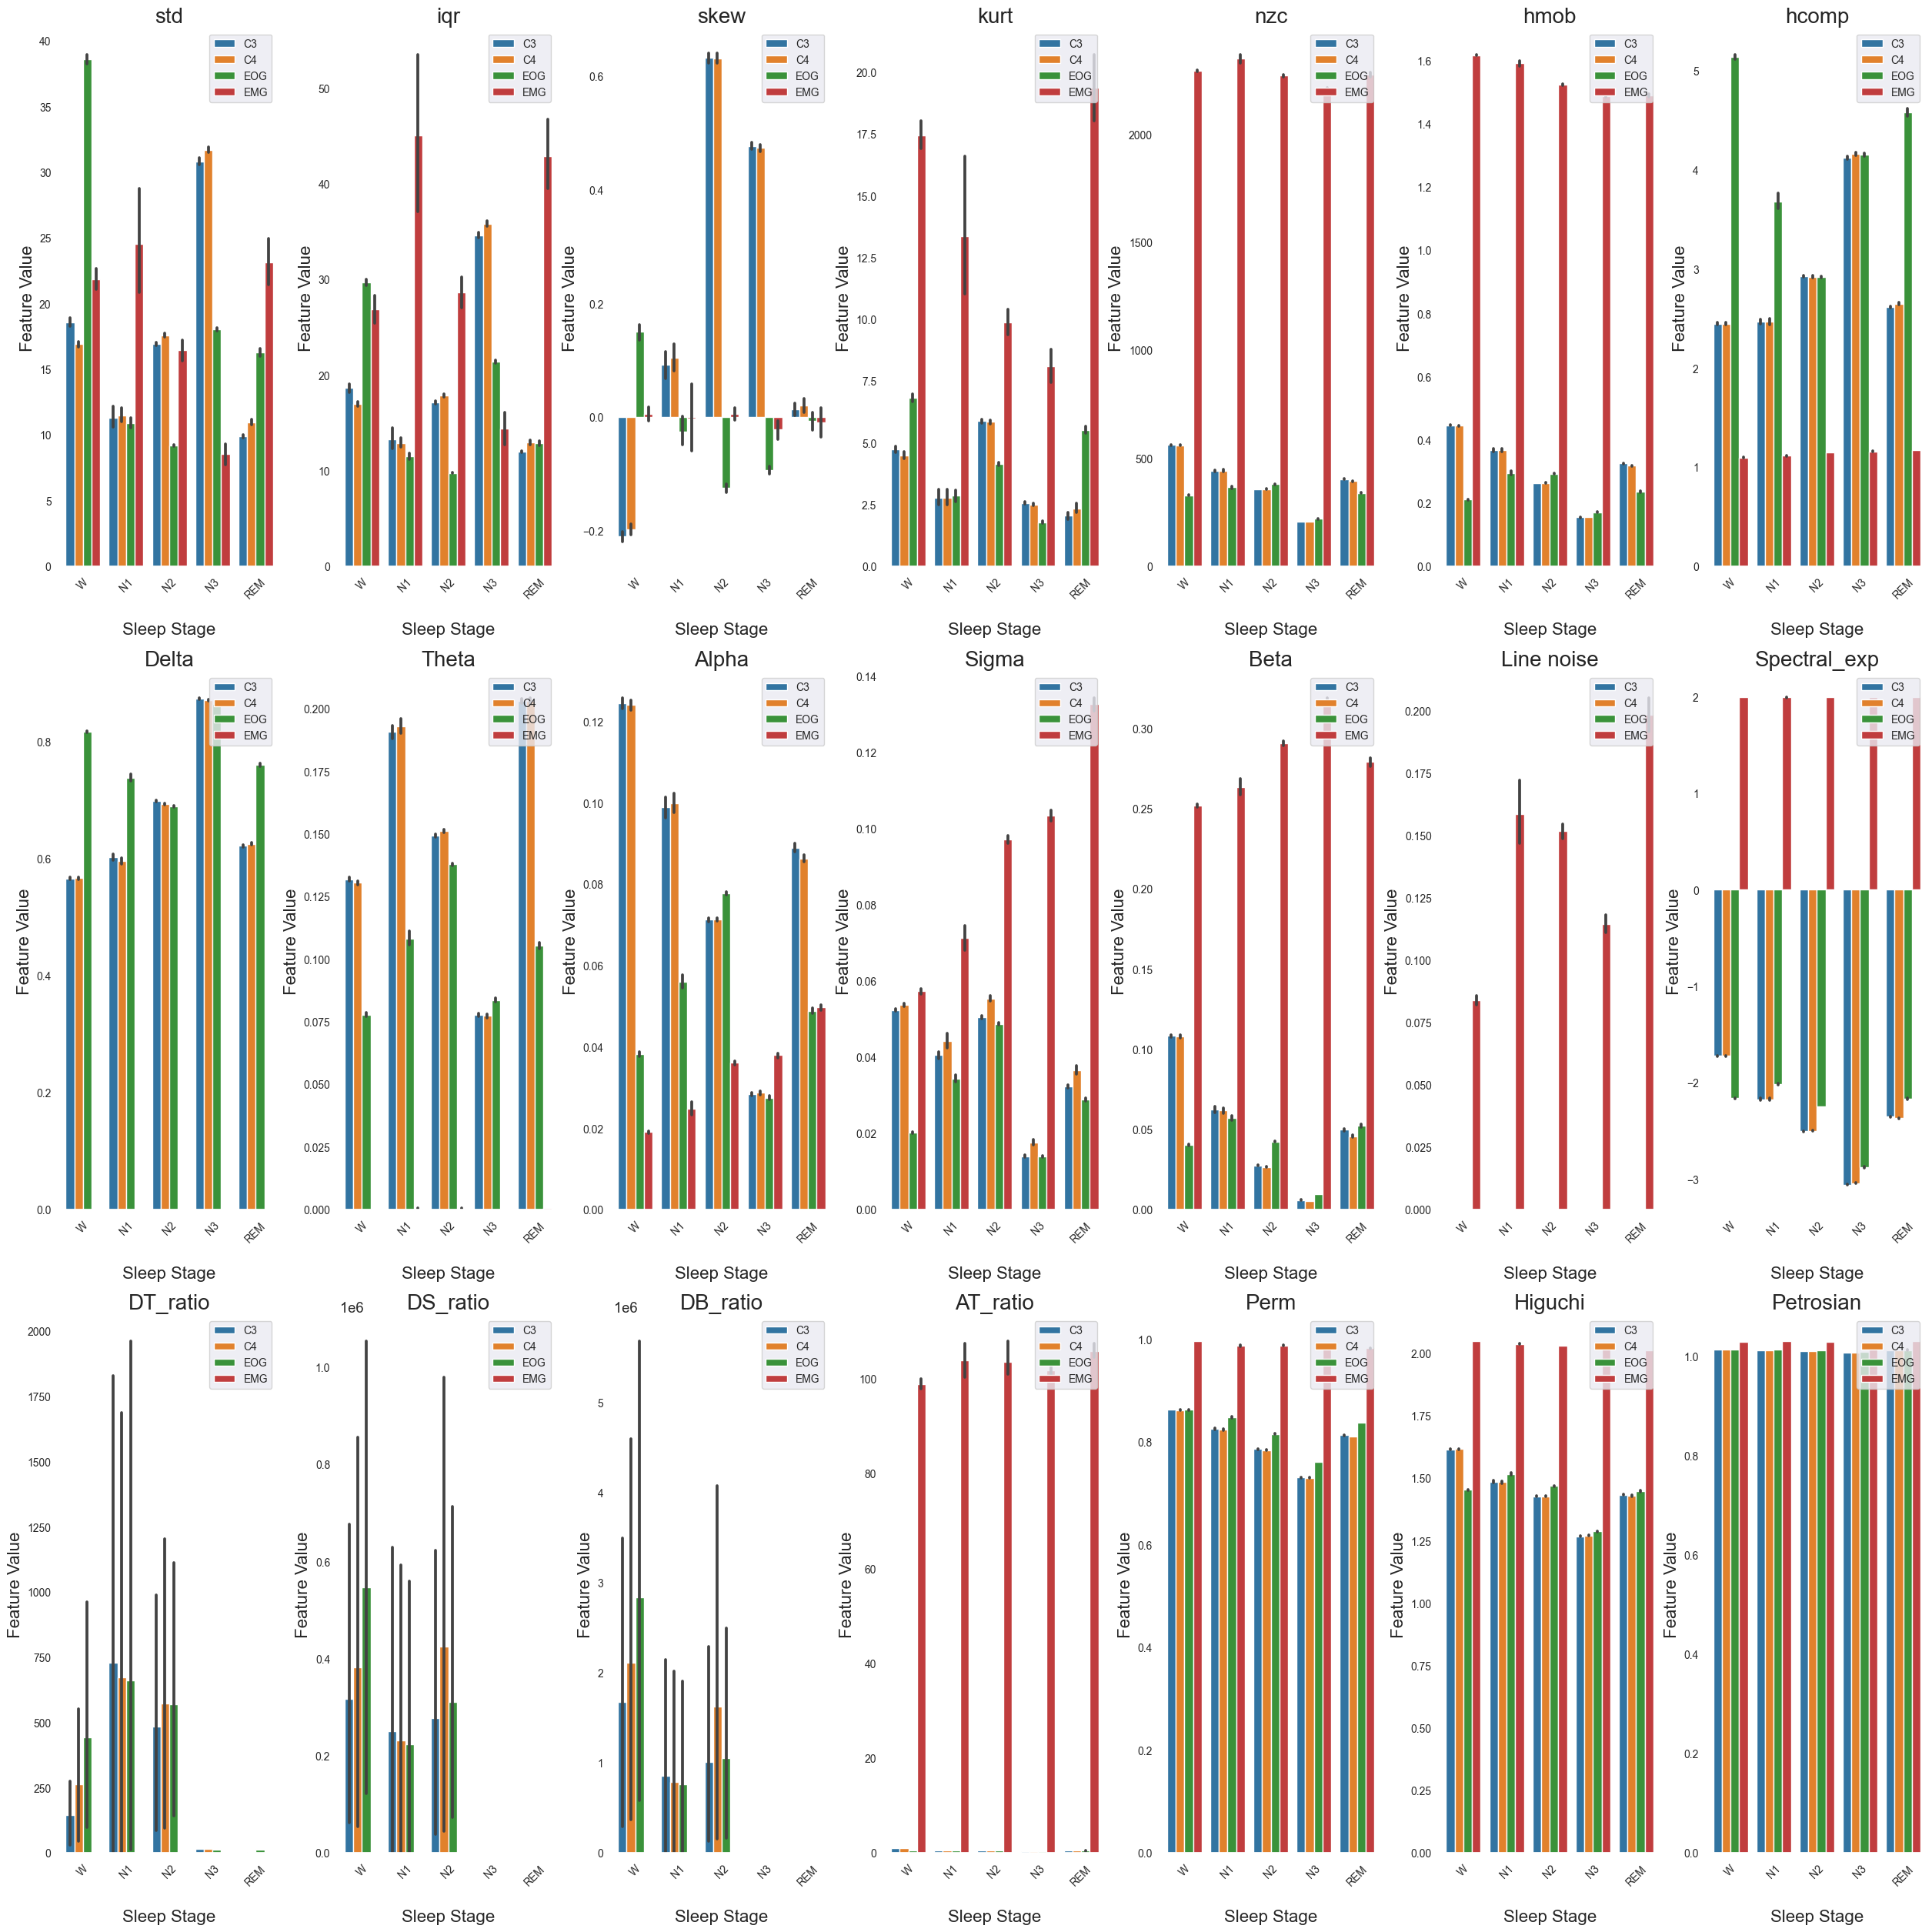

In [10]:
## Plotting
fig, axs = plt.subplots(3, 7, figsize=(25, 25), sharey=False, constrained_layout=True)
num_chans = df_mean['chan'].nunique()
for idx, (col, ax) in enumerate(zip(df_mean.columns[7:], axs.flatten())):
    # # Draw lines connecting points for each subject
    # for subj in df_mean['subject'].unique():
    #     subj_df = df_mean[df_mean['subject'] == subj]
    #     sns.lineplot(ax=ax, x='stage_lab', y=col, data=subj_df, alpha=0.2, 
    #                  color='grey', errorbar=None)

    # # Now overlay scatterplot
    # sns.scatterplot(ax=ax, x='stage_lab', y=col, hue='chan',
    #                 data=df_mean, alpha=.8, s=1)
    
    # Now overlay barplot
    sns.barplot(ax=ax, x='stage_lab', y=col, hue='chan',
                data=df_mean, palette=sns.color_palette("tab10", num_chans))
    
    # Set title and axis labels
    ax.set_title(f'{col}', fontsize=20)
    ax.legend().remove()
    ax.set_xticks(np.arange(0, 5, 1))
    ax.set_xticklabels(['W', 'N1', 'N2', 'N3', 'REM'])
    ax.set_xlim([-0.5, 4.5])
    ax.grid(True)
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right', prop={'size': 10})
    ax.set_xlabel('Sleep Stage', fontsize=16, labelpad=20)  # Adjusted labelpad here
    ax.set_ylabel('Feature Value', fontsize=16)
plt.show()
fig.savefig(f'/media/administrator/data/cfs/figures/unscaled_features.png')

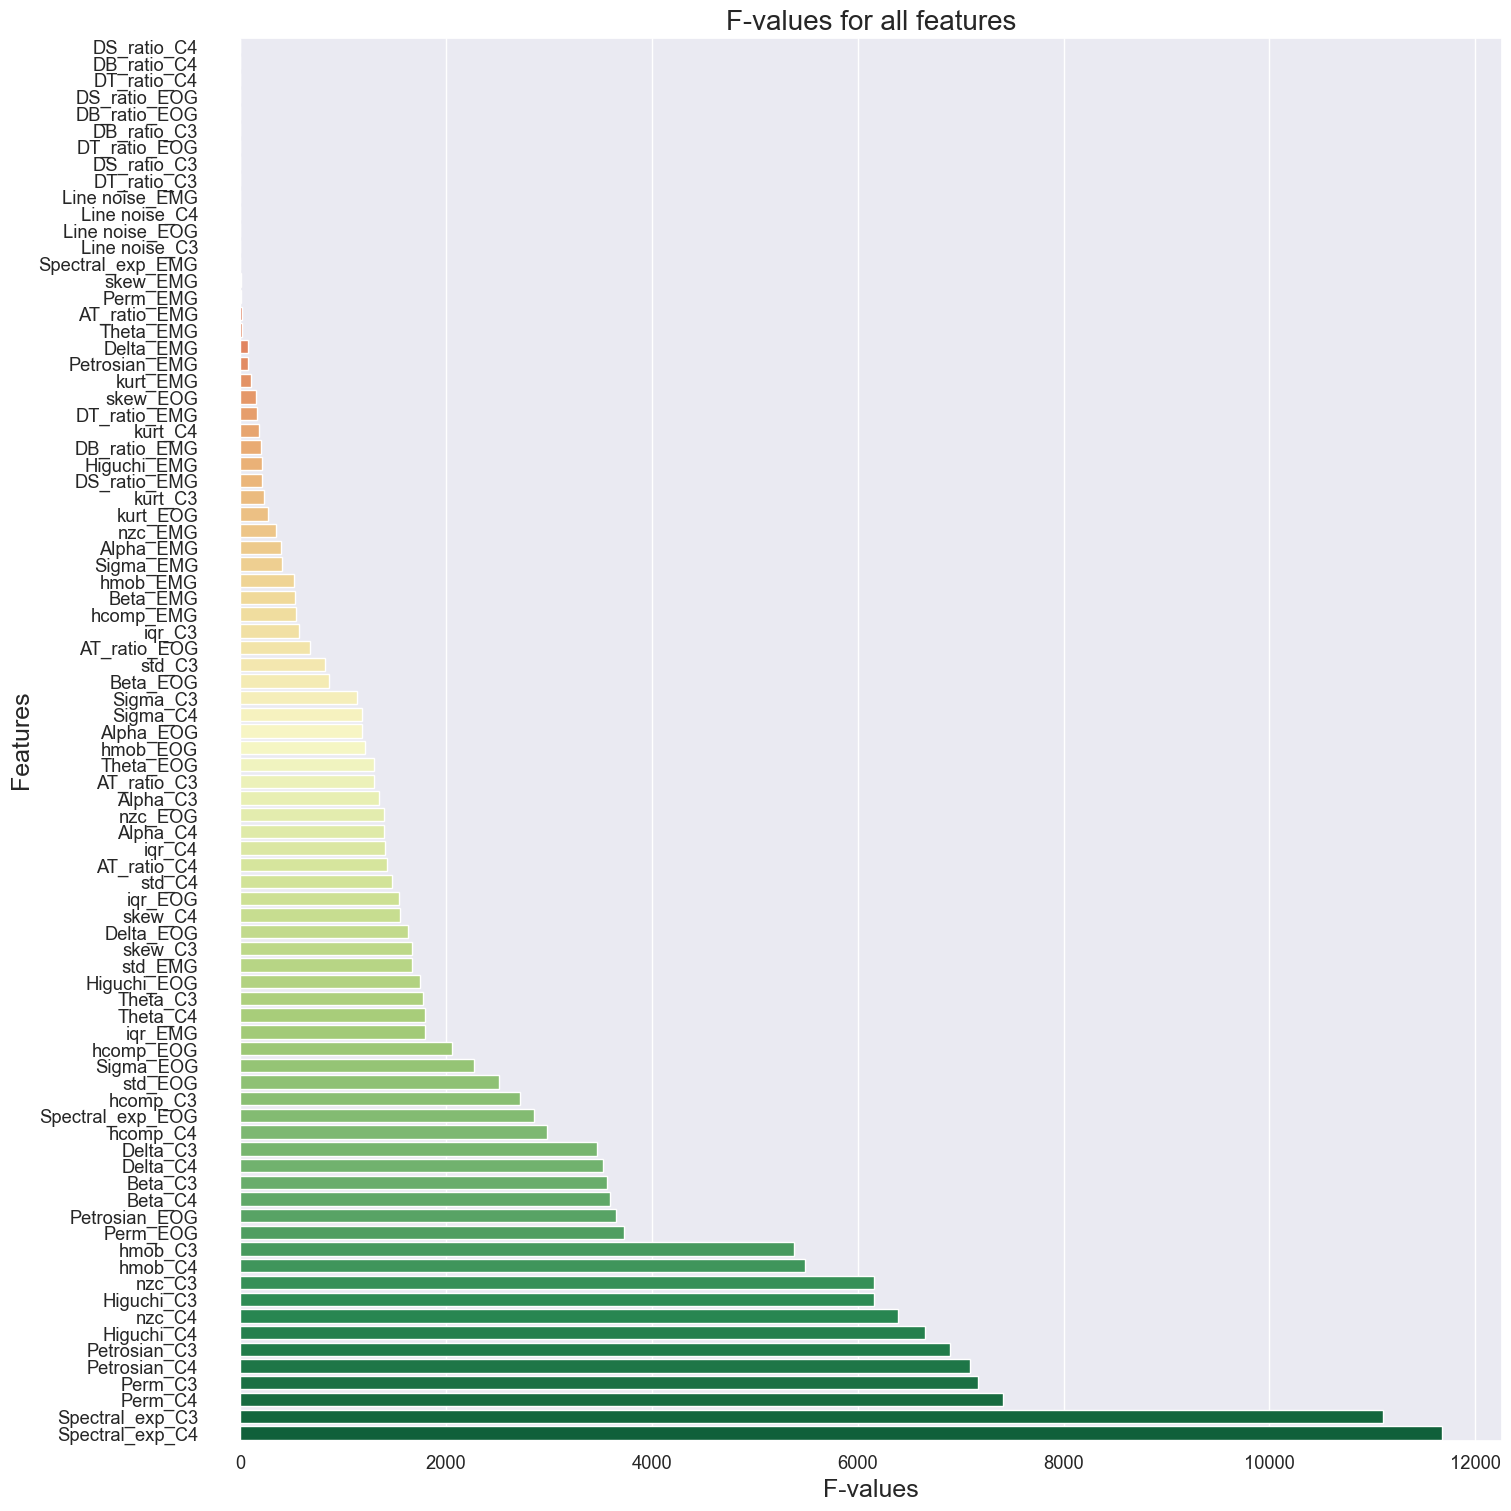

In [358]:
## Extract sorted F-values
# Convert to indexed dataframe
df_fvals = df_mean.set_index(['chan','set','subject','epoch','stage_lab']).loc[(['C3', 'C4', 'EOG', 'EMG'], 
                                                                               ['testing']), df_eeg.columns[2:-5]].unstack(level='chan') # type: ignore
df_fvals.columns = list([f"{x[0]}_{x[1]}" for x in df_fvals.columns])

fvals = pd.Series(f_classif(X=df_fvals,  
                            y=df_fvals.reset_index().stage_lab)[0], 
                            index=df_fvals.columns,
                            ).sort_values()

# Plot best features
fig, axs = plt.subplots(figsize=(15, 15), constrained_layout=True)
sns.barplot(y=fvals.index, x=fvals, palette='RdYlGn', ax=axs)
axs.set_xlabel('F-values', fontsize=18)
axs.set_ylabel('Features', fontsize=18)
axs.set_title('F-values for all features', fontsize=20)
axs.tick_params(axis='y', pad=24)
plt.show()
fig.savefig(f'/media/administrator/data/cfs/figures/fvals.png')

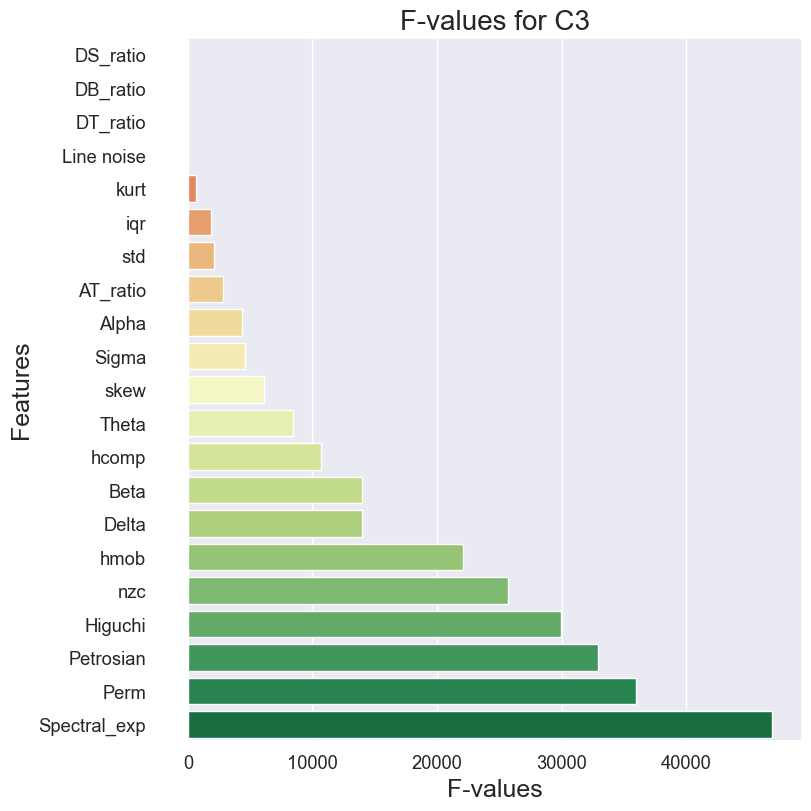

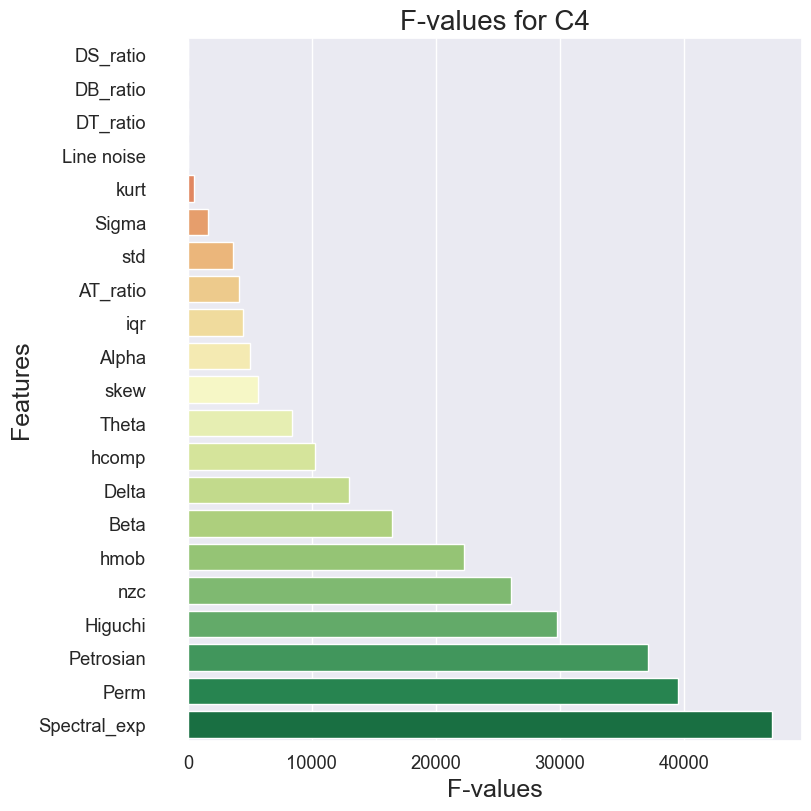

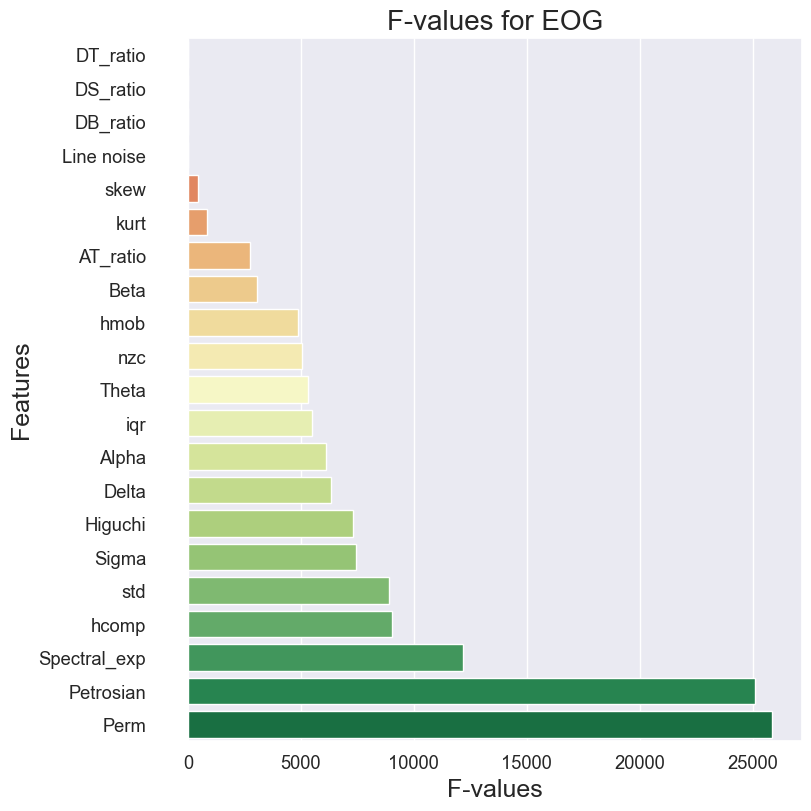

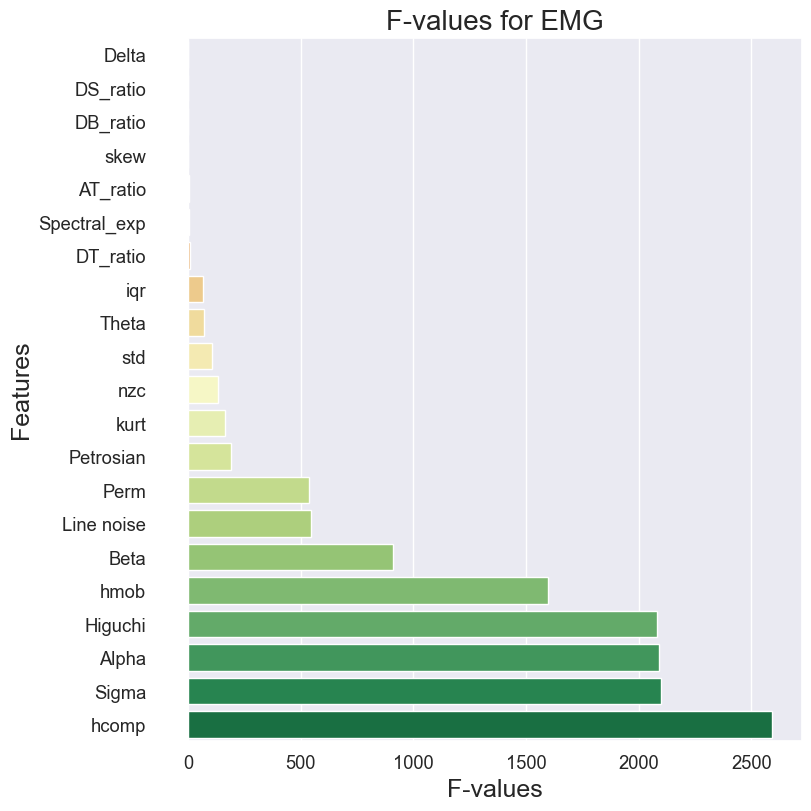

In [362]:
## Do same as above but for each channel separately
# Convert to indexed dataframe
df_fvals = df_mean.set_index(['set','subject','epoch','stage_lab','stage','color'])
# Plot best features for each channel separately
for chan in df_fvals.chan.unique():
    fig, axs = plt.subplots(figsize=(8, 8), constrained_layout=True)
    fvals = pd.Series(f_classif(X=df_fvals[df_fvals.chan==chan].drop(columns=['chan']),
                                y=df_fvals[df_fvals.chan==chan].reset_index().stage_lab)[0],
                                index=df_fvals[df_fvals.chan==chan].drop(columns=['chan']).columns,
                                ).sort_values()
    sns.barplot(y=fvals.index, x=fvals, palette='RdYlGn', ax=axs)
    axs.set_xlabel('F-values', fontsize=18)
    axs.set_ylabel('Features', fontsize=18)
    axs.set_title(f'F-values for {chan}', fontsize=20)
    axs.tick_params(axis='y', pad=24)
    plt.show()
    fig.savefig(f'/media/administrator/data/cfs/figures/fvals_{chan}.png')

### Shapley value feature selection

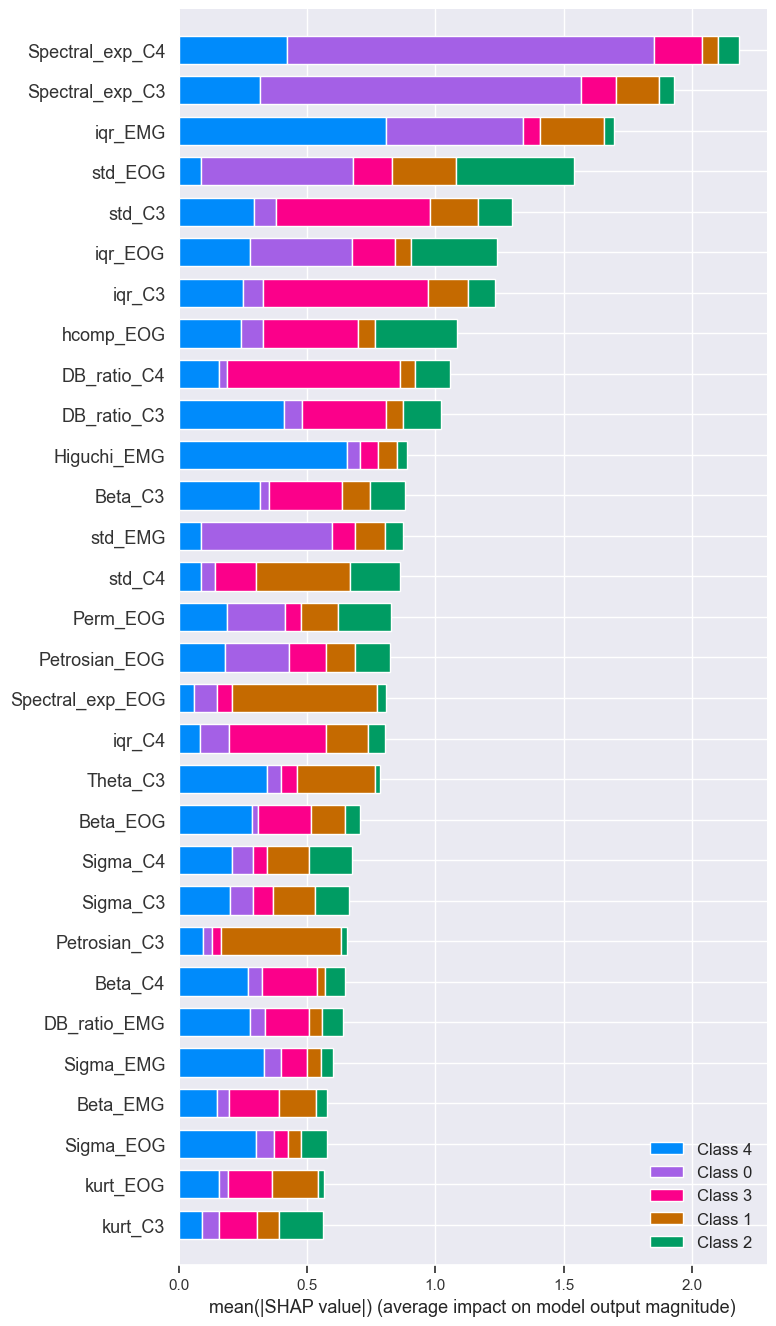

In [15]:
## Feature importance with shapely values

# Create Tree Explainer object that can calculate shap values
explainer = shap.TreeExplainer(lgbm)

# train data 
unique_chans = df_eeg.chan.unique()
shap_df_train = df_eeg.copy().set_index(['chan', 'set', 'subject','epoch']).loc[(unique_chans, ['training']),
                                                                                df_eeg.columns[2:-4]].unstack(level='chan') # type: ignore
shap_df_train.columns = list([f"{x[0]}_{x[1]}" for x in shap_df_train.columns])

# testing data to explain
shap_df_test = df_eeg.copy().set_index(['chan', 'set', 'subject','epoch']).loc[(unique_chans, ['testing']),
                                                                                df_eeg.columns[2:-4]].unstack(level='chan') # type: ignore
shap_df_test.columns = list([f"{x[0]}_{x[1]}" for x in shap_df_test.columns])

# get shap values for test data
shap_values = explainer.shap_values(shap_df_test)

# plot shap values
shap.summary_plot(shap_values, feature_names=shap_df_test.columns, max_display=30)

# Aggregate SHAP values
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=1)

# Rank the features for each class
feature_rank = pd.DataFrame(mean_abs_shap_values.T, 
                            columns=['Class {}'.format(i) for i in range(5)], 
                            index=shap_df_test.columns)
feature_rank['Average Importance'] = feature_rank.mean(axis=1)
feature_rank = feature_rank.sort_values(by='Average Importance', ascending=False)
feature_rank.to_csv(feat_path + "shap_rank_lgbm.csv")

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


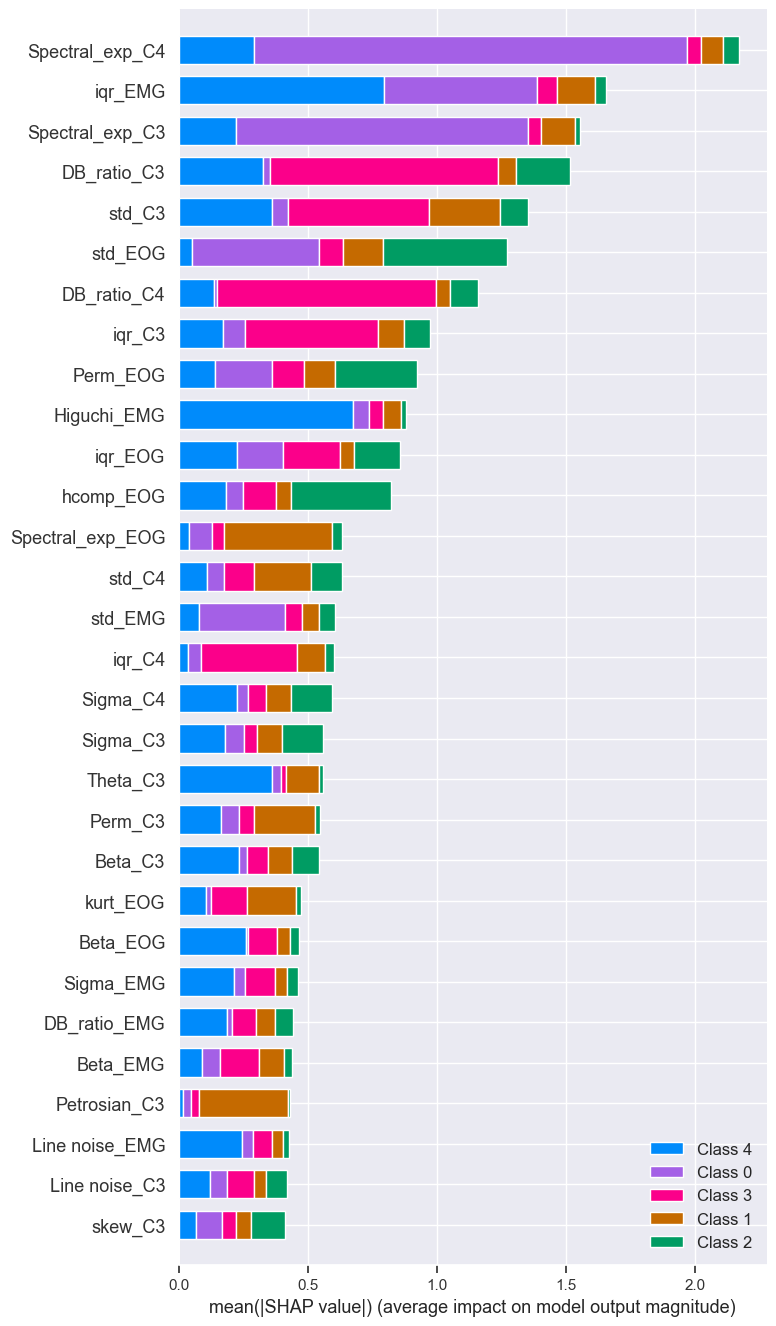

In [14]:
# Create Tree Explainer object that can calculate shap values
explainer = shap.TreeExplainer(XGBoost) 

# get shap values for test data
shap_values = explainer.shap_values(shap_df_test)

# plot shap values
shap.summary_plot(shap_values, feature_names=shap_df_test.columns, max_display=30)

# Aggregate SHAP values
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=1)

# Rank the features for each class
feature_rank = pd.DataFrame(mean_abs_shap_values.T, 
                            columns=['Class {}'.format(i) for i in range(5)], 
                            index=shap_df_test.columns)
feature_rank['Average Importance'] = feature_rank.mean(axis=1)
feature_rank = feature_rank.sort_values(by='Average Importance', ascending=False)
feature_rank.to_csv(feat_path + "shap_rank_xgboost.csv")

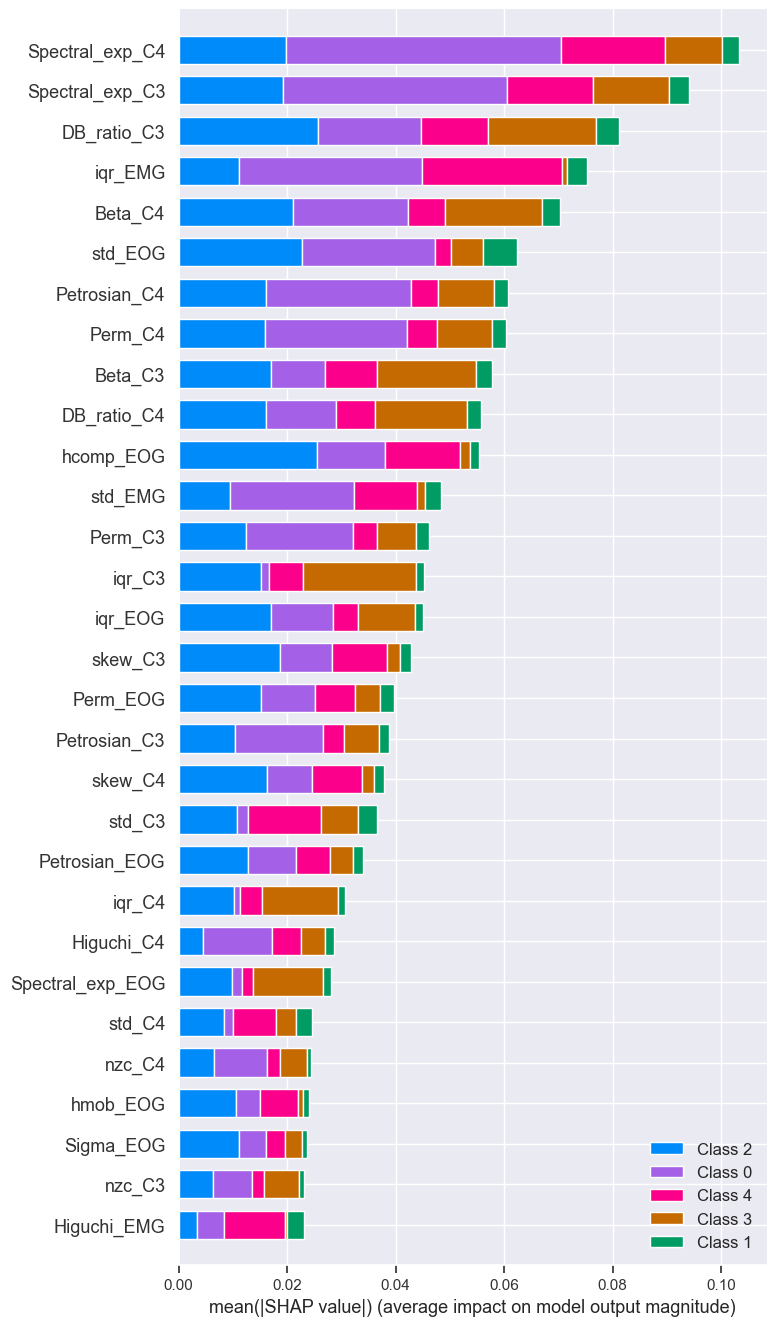

In [21]:
# Create Tree Explainer object that can calculate shap values
explainer = shap.TreeExplainer(rf) 

# get shap values for test data
shap_values = explainer.shap_values(shap_df_test)

# plot shap values
shap.summary_plot(shap_values, feature_names=shap_df_test.columns, max_display=30)

# Aggregate SHAP values
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=1)

# Rank the features for each class
feature_rank = pd.DataFrame(mean_abs_shap_values.T, 
                            columns=['Class {}'.format(i) for i in range(5)], 
                            index=shap_df_test.columns)
feature_rank['Average Importance'] = feature_rank.mean(axis=1)
feature_rank = feature_rank.sort_values(by='Average Importance', ascending=False)
feature_rank.to_csv(feat_path + "shap_rank_rf.csv")

#### Shapley value reclassification

In [9]:
## Reclassify based on Shaply importances
# load shap feature importances
feature_rank = pd.read_csv(feat_path + "shap_rank_lgbm.csv", index_col=0)

In [17]:
f1_scores = []
for idx in range(1, len(feature_rank.index)):
    # CV to resplit each time 
    df = train_test_feature_split(df_eeg, df_ecg=None, pca=False, 
                                  kind='pandas', use_smote=False)
    
    shap_df_train = df.set_index(['chan', 'set', 'subject','epoch', 'stage']).loc[(['C3', 'C4', 'EOG', 'EMG'],  # type: ignore
                                                                                   ['training']),
                                                                                   df.columns[2:-4]].unstack(level='chan')
    shap_df_train.columns = list([f"{x[0]}_{x[1]}" for x in shap_df_train.columns])
    
    shap_df_test = df.set_index(['chan', 'set', 'subject','epoch','stage']).loc[(['C3', 'C4', 'EOG', 'EMG'], 
                                                                                 ['testing']),
                                                                                 df.columns[2:-4]].unstack(level='chan')
    shap_df_test.columns = list([f"{x[0]}_{x[1]}" for x in shap_df_test.columns])
    
    
    shap_df_train_shap = shap_df_train[feature_rank.index[0:idx]]
    shap_df_test_shap = shap_df_test[feature_rank.index[0:idx]]
    clf = lightgbm_classification(X_train = shap_df_train_shap, 
                                  y_train = shap_df_train_shap.reset_index()['stage'].to_numpy(), 
                                  X_test = shap_df_test_shap,
                                  y_test = shap_df_test_shap.reset_index()['stage'].to_numpy(),
                                  class_weight=False)
    
    # Metrics
    event_id = {'Wake': 0,
                'Stage 1': 1,
                'Stage 2': 2,
                'Stage 3': 3,
                'REM': 4} 
    
    # prediction    
    y_pred = clf.predict(shap_df_test_shap)
    
    # accuracy report, confusion matrix, classification reports
    f1_scores.append([idx, f1_score(y_test, y_pred, average='weighted')])
  
# extract counts & f1-scores    
feat_count = [f1_scores[i][0] for i in range(len(f1_scores))]
f1s = [f1_scores[i][1] for i in range(len(f1_scores))]

Accuracy score: 0.754600833600513
              precision    recall  f1-score   support

        Wake       0.83      0.90      0.87      4829
     Stage 1       0.00      0.00      0.00       328
     Stage 2       0.66      0.90      0.76      5960
     Stage 3       0.89      0.78      0.83      2634
         REM       0.00      0.00      0.00      1844

    accuracy                           0.75     15595
   macro avg       0.48      0.52      0.49     15595
weighted avg       0.66      0.75      0.70     15595



Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Accuracy score: 0.7519717858287913
              precision    recall  f1-score   support

        Wake       0.82      0.90      0.86      4829
     Stage 1       0.00      0.00      0.00       328
     Stage 2       0.68      0.87      0.76      5960
     Stage 3       0.89      0.80      0.84      2634
         REM       0.35      0.06      0.11      1844

    accuracy                           0.75     15595
   macro avg       0.55      0.53      0.51     15595
weighted avg       0.71      0.75      0.71     15595



Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Accuracy score: 0.7921769798012184
              precision    recall  f1-score   support

        Wake       0.90      0.91      0.91      4829
     Stage 1       0.14      0.00      0.01       328
     Stage 2       0.72      0.83      0.77      5960
     Stage 3       0.87      0.80      0.83      2634
         REM       0.64      0.49      0.55      1844

    accuracy                           0.79     15595
   macro avg       0.65      0.61      0.61     15595
weighted avg       0.78      0.79      0.78     15595

Accuracy score: 0.8202629047771721
              precision    recall  f1-score   support

        Wake       0.93      0.94      0.93      4829
     Stage 1       0.00      0.00      0.00       328
     Stage 2       0.75      0.87      0.80      5960
     Stage 3       0.87      0.82      0.85      2634
         REM       0.71      0.50      0.58      1844

    accuracy                           0.82     15595
   macro avg       0.65      0.62      0.63     15595
weighte

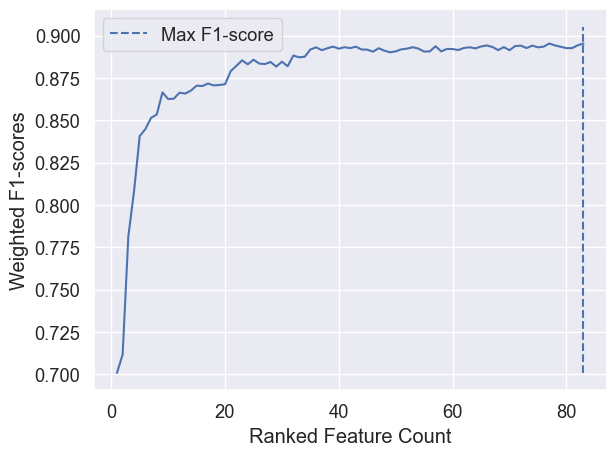

In [27]:
# Plot curve
plt.figure()
plt.plot(feat_count, f1s, linestyle='-', color='b')
plt.xlabel('Ranked Feature Count')
plt.ylabel('Weighted F1-scores')
plt.vlines(np.argmax(f1s) + 1, ymin=min(f1s), ymax=max(f1s)+.01,
           linestyles='dashed', label='Max F1-score')
plt.grid(True)
plt.tight_layout()
plt.legend()

### Recursive feature elimination

Load and plot recursive feature elimination results for random forest and lightGBM.

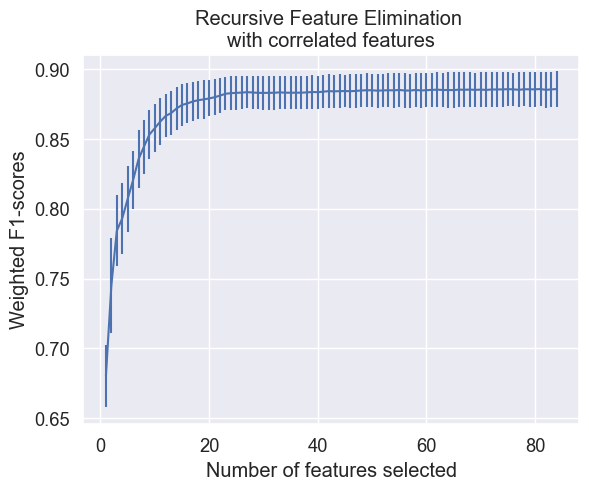

In [29]:
## Recursive feature elimination with cross validation - lightGBM
rfe_lightgbm = pickle.load(open(feat_path + "rfe_lgbm.p", "rb"))
plot_rfe(rfe_lightgbm)
# Access the selected features
selected_features_lightgbm = rfe_lightgbm.support_
# Access the feature ranking
feature_ranking_lightgbm = rfe_lightgbm.ranking_

In [41]:
selected_features_lightgbm = pd.DataFrame(selected_features_lightgbm, index=shap_df_test.columns)
selected_features_lightgbm[selected_features_lightgbm[0] == False].index.tolist()

[]

In [385]:
feature_ranking_lightgbm

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

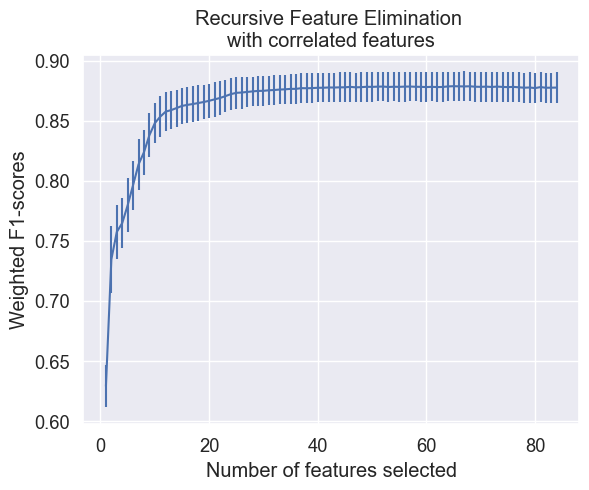

In [43]:
## Recursive feature elimination with cross validation - RF
rfe_rf = pickle.load(open(feat_path + "rfe_rf.p", "rb"))
plot_rfe(rfe_rf)
# Access the selected features
selected_features_rf = rfe_rf.support_
# Access the feature ranking
feature_ranking_rf = rfe_rf.ranking_

In [44]:
selected_features_rf = pd.DataFrame(selected_features_rf, index=shap_df_test.columns)
# get false features as a list
selected_features_rf[selected_features_rf[0] == False].index.tolist()

['skew_EMG',
 'skew_EOG',
 'kurt_EMG',
 'hcomp_C3',
 'hcomp_C4',
 'Delta_EMG',
 'Delta_EOG',
 'Theta_EOG',
 'Line noise_C3',
 'Line noise_C4',
 'Line noise_EOG',
 'Spectral_exp_EMG',
 'DT_ratio_EMG',
 'DT_ratio_EOG',
 'DS_ratio_EMG',
 'DB_ratio_EMG',
 'AT_ratio_EMG',
 'AT_ratio_EOG',
 'Perm_EMG']

In [54]:
feature_ranking_rf

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 11, 13,  1,  1,  4,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  8, 10,  1,  1,  1,  1, 15,  2,  1,  1,
        1,  6,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 18, 17,  1,
       19,  1,  1, 20,  1,  1,  1,  7,  3,  1,  1, 14,  1,  1,  1, 16,  1,
        1,  1, 12,  9,  1,  1,  5,  1,  1,  1,  1,  1,  1,  1,  1,  1])

## Cross Validation of Classifiers on Test Data

### Pre-process per subject data

In [62]:
## load all classifiers from /media/administrator/data/cfs/models
import glob
model_path = "/media/administrator/data/cfs/models/"
for file in glob.glob(model_path + "*.p"):
    #print(file)
    # assign name of loaded model
    model_name = file.split("/")[-1].split(".")[0]
    # load model
    model = pickle.load(open(file, "rb"))
    # reassign variable name based on model_name
    exec(model_name + "= model")

/media/administrator/data/cfs/models/lgbm_model_new_cfs_model2.p
/media/administrator/data/cfs/models/rf_model_new_cfs_model1.p
/media/administrator/data/cfs/models/lgbm_model_new_cfs_model5.p
/media/administrator/data/cfs/models/xgboost_model_new_cfs_model5.p
/media/administrator/data/cfs/models/lgbm_model_new_cfs_model3.p
/media/administrator/data/cfs/models/nn_model_new_cfs_model4.p
/media/administrator/data/cfs/models/nn_model_new_cfs_model1.p
/media/administrator/data/cfs/models/nn_model_new_cfs_model6.p
/media/administrator/data/cfs/models/nn_model_new_cfs_model2.p
/media/administrator/data/cfs/models/xgboost_model_new_cfs_model3.p
/media/administrator/data/cfs/models/xgboost_model_new_cfs_model4.p
/media/administrator/data/cfs/models/lgbm_model_new_cfs_model6.p
/media/administrator/data/cfs/models/lgbm_model_new_cfs_model1.p
/media/administrator/data/cfs/models/xgboost_model_new_cfs_model6.p
/media/administrator/data/cfs/models/nn_model_new_cfs_model3.p
/media/administrator/data

['lgbm_model_new_cfs_model2',
 'rf_model_new_cfs_model1',
 'lgbm_model_new_cfs_model5',
 'xgboost_model_new_cfs_model5',
 'lgbm_model_new_cfs_model3',
 'nn_model_new_cfs_model4',
 'nn_model_new_cfs_model1',
 'nn_model_new_cfs_model6',
 'nn_model_new_cfs_model2',
 'xgboost_model_new_cfs_model3',
 'xgboost_model_new_cfs_model4',
 'lgbm_model_new_cfs_model6',
 'lgbm_model_new_cfs_model1',
 'xgboost_model_new_cfs_model6',
 'nn_model_new_cfs_model3',
 'xgboost_model_new_cfs_model2',
 'nn_model_new_cfs_model5',
 'xgboost_model_new_cfs_model1',
 'lgbm_model_new_cfs_model4',
 'rf_model_new_cfs_model3',
 'rf_model_new_cfs_model4',
 'rf_model_new_cfs_model2',
 'rf_model_new_cfs_model5',
 'rf_model_new_cfs_model6']

In [28]:
new_path = '/media/administrator/data/Study_1_data/Statistics/Classifier_validation/All/'

def group_classification_validation(df, model_id, event_id, target_names):     
    new_path = '/media/administrator/data/Study_1_data/Statistics/Classifier_validation/All/'
    
    y_tests_all = []
    for idx in range(len(model_id)):
        y_tests_all.append(np.hstack([df[df['model idx']==idx]['Test hypnograms'].to_numpy()[i] for i in range(df[df['model idx']==idx]['Test hypnograms'].shape[0])]))
                   
    y_preds_all = []
    for idx in range(len(model_id)):
        y_preds_all.append(np.hstack([df[df['model idx']==idx]['Pred hypnograms'].to_numpy()[i] for i in range(df[df['model idx']==idx]['Pred hypnograms'].shape[0])]))        
       
    y_scores_all = []
    for idx in range(len(model_id)):
        y_scores_all.append(np.vstack([df[df['model idx']==idx]['Pred probabilities'].to_numpy()[i] for i in range(df[df['model idx']==idx]['Pred probabilities'].shape[0])]))            
                   
    y_cohen_ks_all = []
    for idx in range(len(model_id)):
        y_cohen_ks_all.append(np.hstack([df[df['model idx']==idx]['Cohens Kappa'].to_numpy()[i] for i in range(df[df['model idx']==idx]['Cohens Kappa'].shape[0])]))        
       
    y_phis_all = []
    for idx in range(len(model_id)):
        y_phis_all.append(np.hstack([df[df['model idx']==idx]['Phi'].to_numpy()[i] for i in range(df[df['model idx']==idx]['Phi'].shape[0])]))        
       
    y_f1s_all = []
    for idx in range(len(model_id)):
        y_f1s_all.append(np.hstack([df[df['model idx']==idx]['F1-score'].to_numpy()[i] for i in range(df[df['model idx']==idx]['F1-score'].shape[0])]))       
    
    for idx, (y_pred_all, y_test_all, y_score_all, y_cohen_k_all, y_phi_all, y_f1_all) in enumerate(zip(y_preds_all, y_tests_all, y_scores_all, y_cohen_ks_all, y_phis_all, y_f1s_all)):    
        print("Model: {}".format(model_id[idx]))
        acc = accuracy_score(y_test_all, y_pred_all)
        print("Accuracy score: {}".format(acc))
        confusion = confusion_matrix(y_test_all, y_pred_all)
        print(confusion)
        report = classification_report(y_test_all, y_pred_all, target_names=event_id.keys())
        print(report)
        cm = confusion_matrix(y_test_all, y_pred_all, normalize='true').round(2)
        np.set_printoptions(precision=2)
        print(f'Confusion matrix: \n {cm}' + '\n')
        
        ############## - compute over [] - #############
        # import scikits.bootstrap as bootstrap
        # CI = bootstrap.ci
        #inter_agreement = df.groupby('Cohens Kappa').apply(lambda x:bootstrap.ci(data=x, statfunction=scipy.mean)).round(2)
        inter_agreement = np.nanmean(y_cohen_k_all)
        print(f'The inter-rate agreement is K = {inter_agreement}' + '\n')
        
        # plt.figure()
        # plot_confusion_matrix(path = new_path, cm=cm, target_names=target_names, title=f'Confusion matrix - All Subjects - {model_id[idx]}', 
        #                       save=True, save_name = model_id[idx] + '_all_subj')
        plot_multiclass_ROC(level = 'group level', path = new_path, y_test_all = y_test_all, y_score_all = y_score_all, save_name = model_id[idx] + '_all_subj')
        
        plt.figure()
        sns.heatmap(cm, cmap=plt.cm.Blues,square=True, annot=True, cbar=True, xticklabels=target_names, yticklabels=target_names)
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.xticks(rotation=45)
        plt.yticks(rotation=360)
        plt.title(f'Confusion matrix - All Subjects - {model_id[idx]}')
        plt.tight_layout()
        plt.savefig(new_path + f"confusion_matrix_{model_id[idx] + '_all_subj'}")
        
    #plt.close('all')

In [24]:
# model path
model_path = "/media/administrator/data/cfs/models/"   
# compile sorted list of model names
model_id = [model_name.split("/")[-1].split(".")[0] for model_name in glob.glob(model_path + "*.p")]
sorted_model_names = natsorted(model_id, key=lambda x: x.split('_')[-1])
sorted_model_names.extend([f'rf_model_{idx}_cfs' for idx in range(1,7)])
sorted_model_names.extend(['yasa_model'])

# stage info
event_id ={'Wake':0,
           'Stage 1':1,
           'Stage 2':2,
           'Stage 3':3,
           'REM':4}
target_names=event_id.keys()

# run for all subjects     
#exp_df = df[df.Condition != 'adaption'].reset_index(drop=True)
group_classification_validation(df_cv_results, sorted_model_names, event_id, target_names)

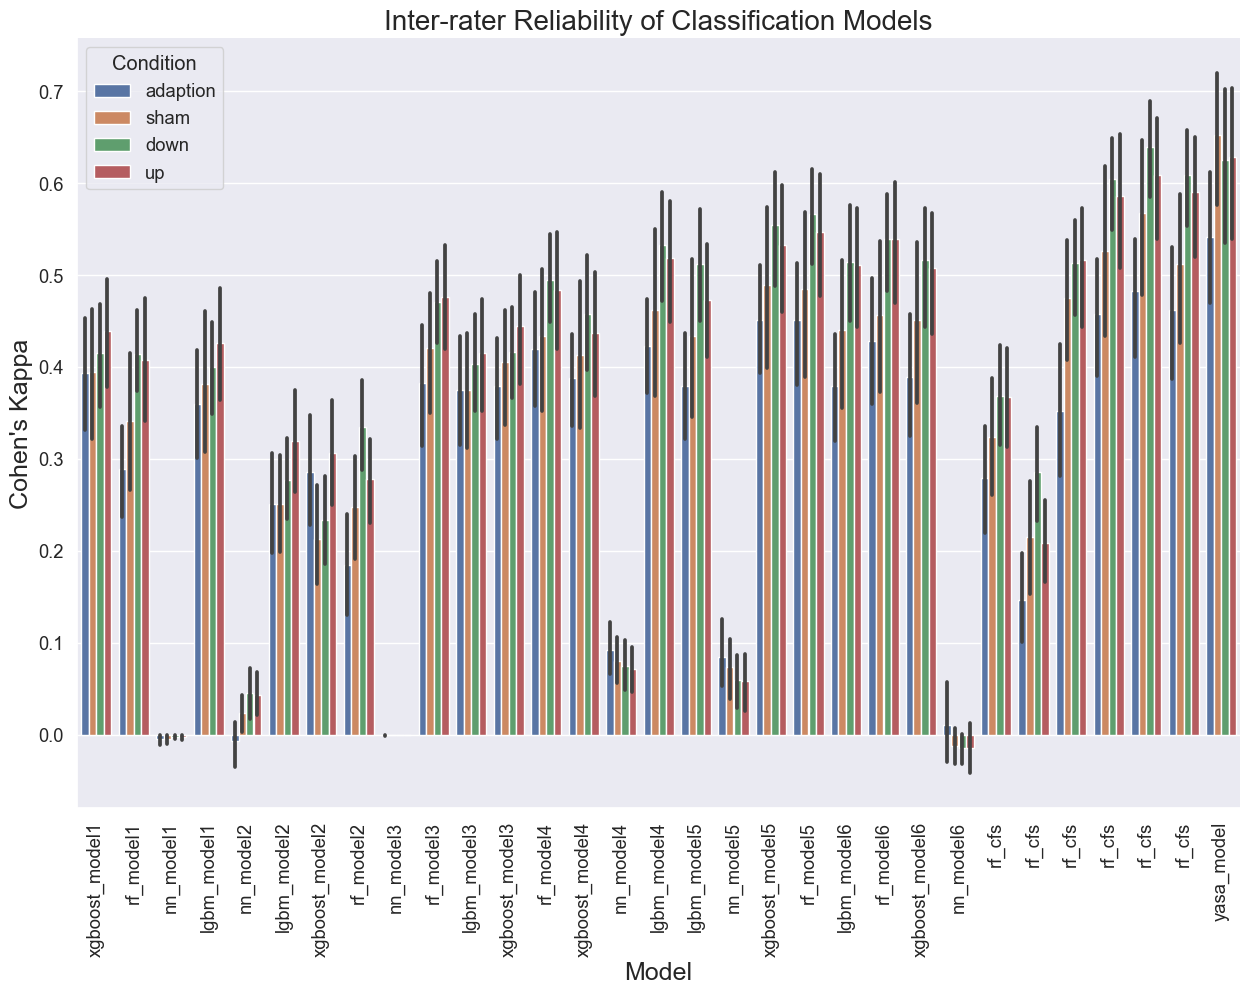

In [43]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.barplot(x = 'model idx', y = 'Cohens Kappa', hue='Condition', data = df_cv_results, ax=ax)
plt.title('Inter-rater Reliability of Classification Models', fontsize=20)
ax.set_xlabel('Model', fontsize=18)
ax.set_ylabel("Cohen's Kappa", fontsize=18)
sorted_model_names_ = [model_name.split("_")[0] + '_' + model_name.split("_")[-1] for model_name in sorted_model_names]
ax.set_xticklabels(sorted_model_names_, rotation=90)
sns.despine()
plt.savefig(new_path + 'cohens_kappa_all_models.png')

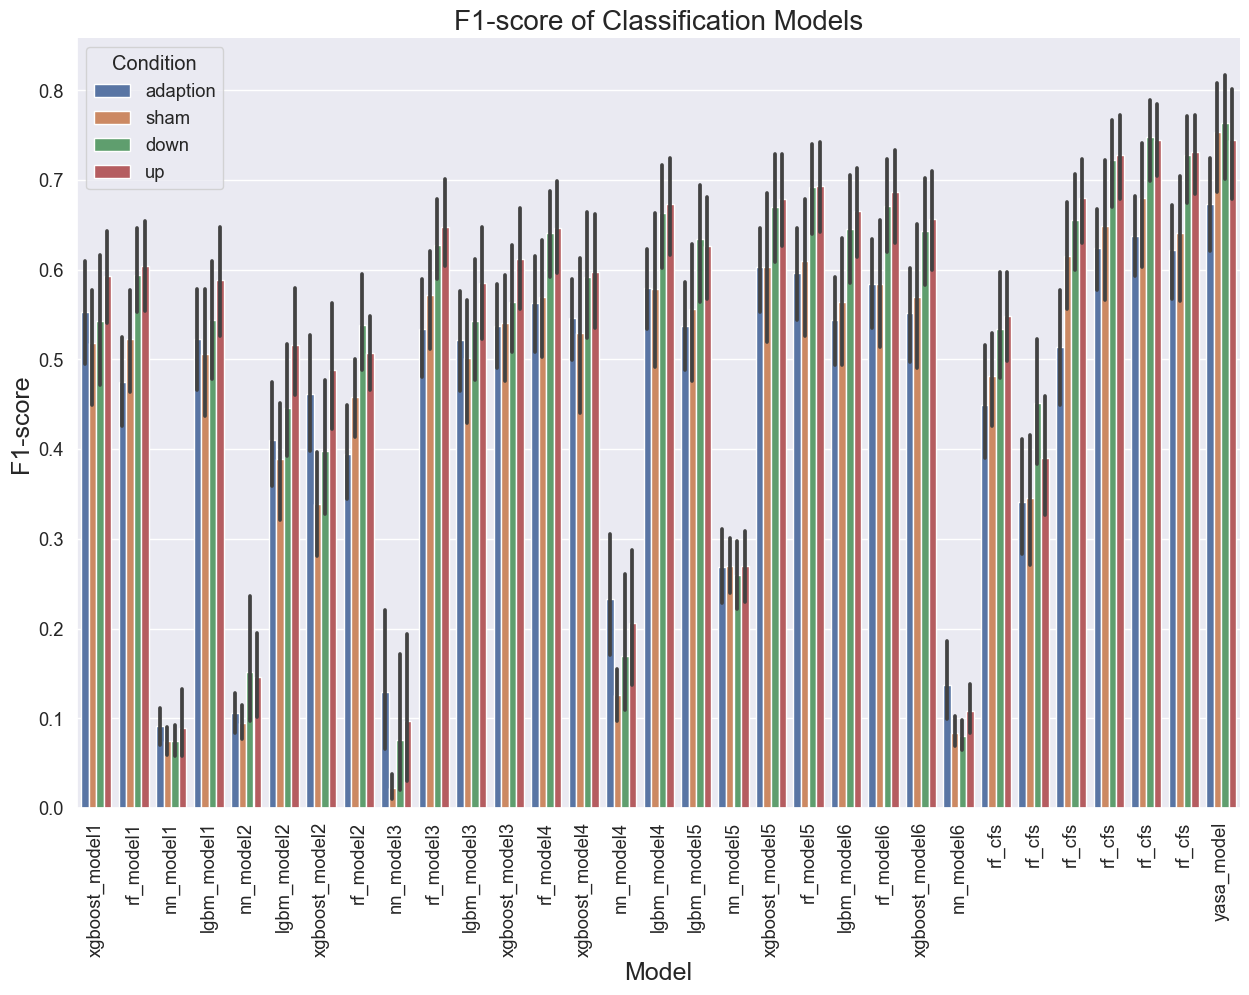

In [42]:
# F1 scores
fig, ax = plt.subplots(figsize=(15, 10))
sns.barplot(x = 'model idx', y = 'F1-score', hue='Condition', data = df_cv_results, ax=ax)
plt.title('F1-score of Classification Models', fontsize=20)
ax.set_xlabel('Model', fontsize=18)
ax.set_ylabel('F1-score', fontsize=18)
sorted_model_names_ = [model_name.split("_")[0] + '_' + model_name.split("_")[-1] for model_name in sorted_model_names]
ax.set_xticklabels(sorted_model_names_, rotation=90)
sns.despine()
plt.savefig(new_path + 'f1_scores_all_models.png')

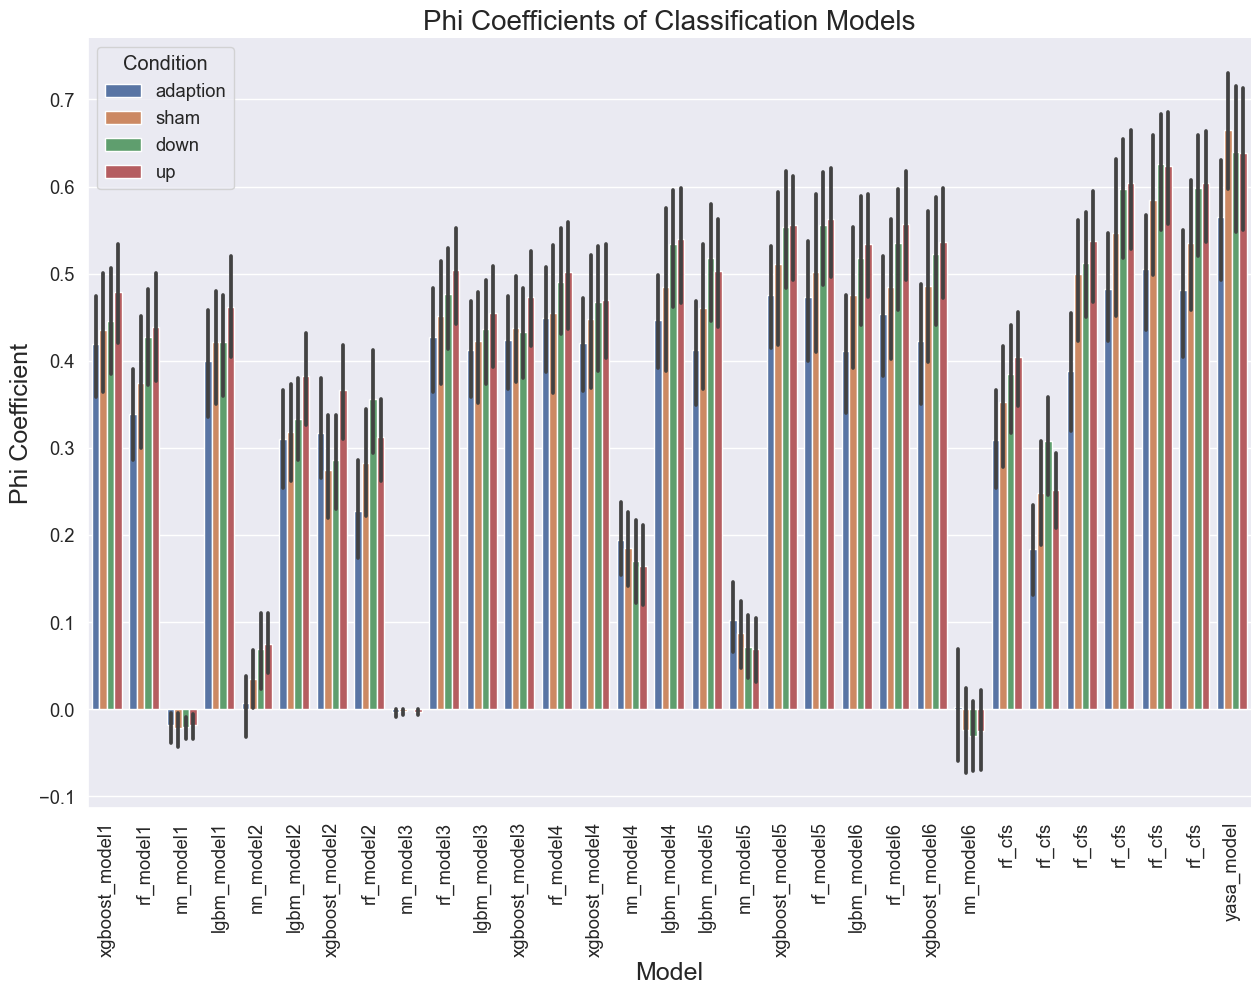

In [41]:
# Phi Coefficients
fig, ax = plt.subplots(figsize=(15, 10))
sns.barplot(x = 'model idx', y = 'Phi', hue='Condition', data = df_cv_results, ax=ax)
plt.title('Phi Coefficients of Classification Models', fontsize=20)
ax.set_xlabel('Model', fontsize=18)
ax.set_ylabel('Phi Coefficient', fontsize=18)
ax.set_xticklabels(sorted_model_names_, rotation=90)
sns.despine()
plt.savefig(new_path + 'phi_scores_all_models.png')

In [159]:
# load dataframe
df_cv_results = pickle.load(open('/media/administrator/data/Study_1_data/Statistics/Classifier_validation/Results.p', 'rb'))

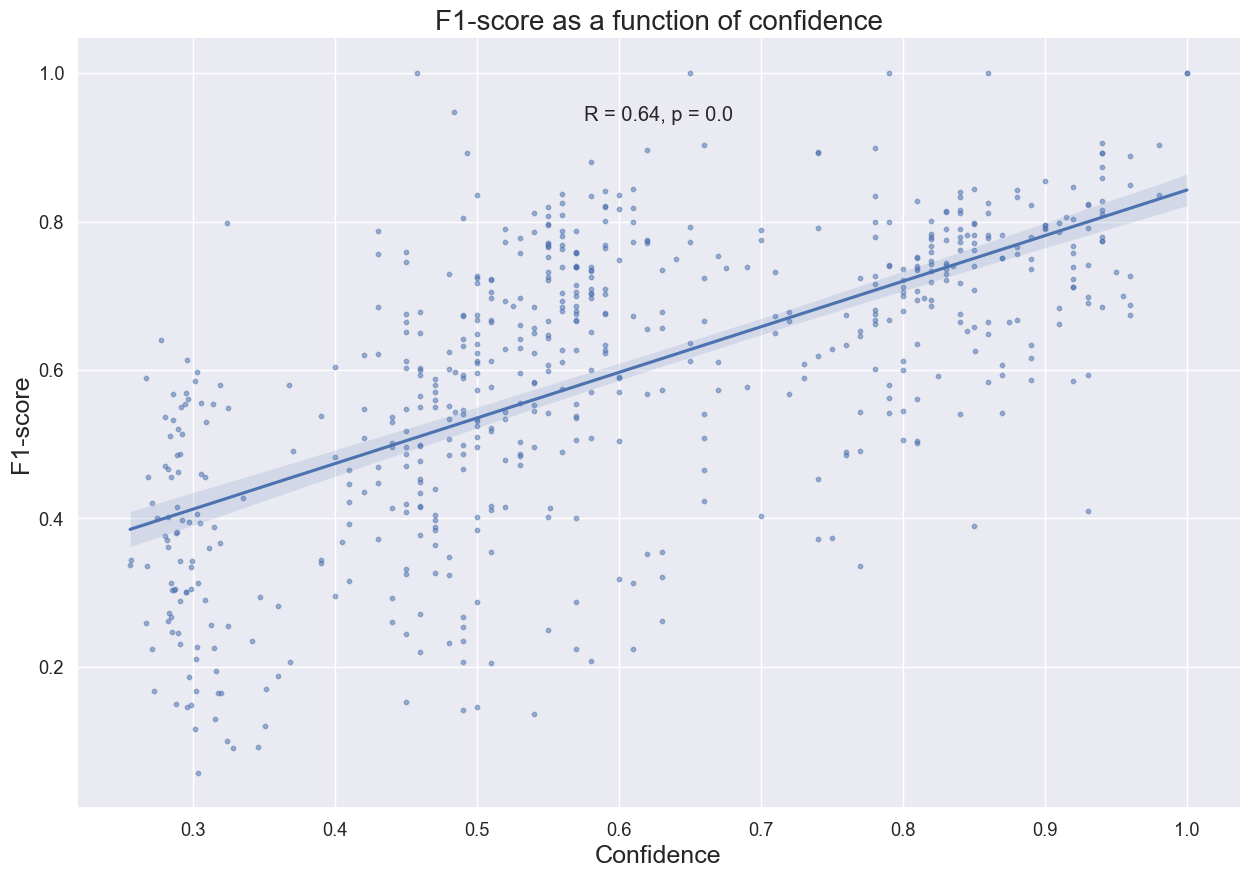

In [177]:
## plot f1 scores as a function of confidence, utilizing the mean probability of the predicted class from the dataframe
# calculate confidence as highest probability of predicted epoch 
df_cv_results['Confidence'] = df_cv_results['Pred probabilities'].apply(lambda x: np.median(np.max(x, axis=1)))
# plot
fig, ax = plt.subplots(figsize=(15, 10))
#sns.scatterplot(x = 'Confidence', y = 'F1-score', data = df_cv_results, ax=ax, s=10, alpha=0.5)
# Assuming that 'Confidence' and 'F1-score' are numeric data
df_cv_results = df_cv_results.astype({'Confidence': 'float', 'F1-score': 'float'})
# Select top 6 performing models
top_models = df_cv_results[df_cv_results['model idx'].isin([24,25,26,27,28,29])]
# Regression plot for top 6 performing models
sns.regplot(x = 'Confidence', y = 'F1-score', data = top_models, ax=ax, scatter_kws={'s':10, 'alpha':0.5})
# Compute the correlation coefficient and p-value
import scipy.stats as stats
r_value, p_val = stats.pearsonr(top_models['Confidence'], top_models['F1-score'])
#r_value = round(top_models['Confidence'].corr(top_models['F1-score']), 2)
# Add the correlation coefficient to the plot
ax.text(0.5, 0.9, f"R = {r_value.round(2)}, p = {p_val.round(4)}", 
        horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
plt.title('F1-score as a function of confidence', fontsize=20)
ax.set_xlabel('Confidence', fontsize=18)
ax.set_ylabel('F1-score', fontsize=18)
sns.despine()
plt.savefig(new_path + 'f1_scores_confidence.png')

Mean of empty slice
All-NaN slice encountered


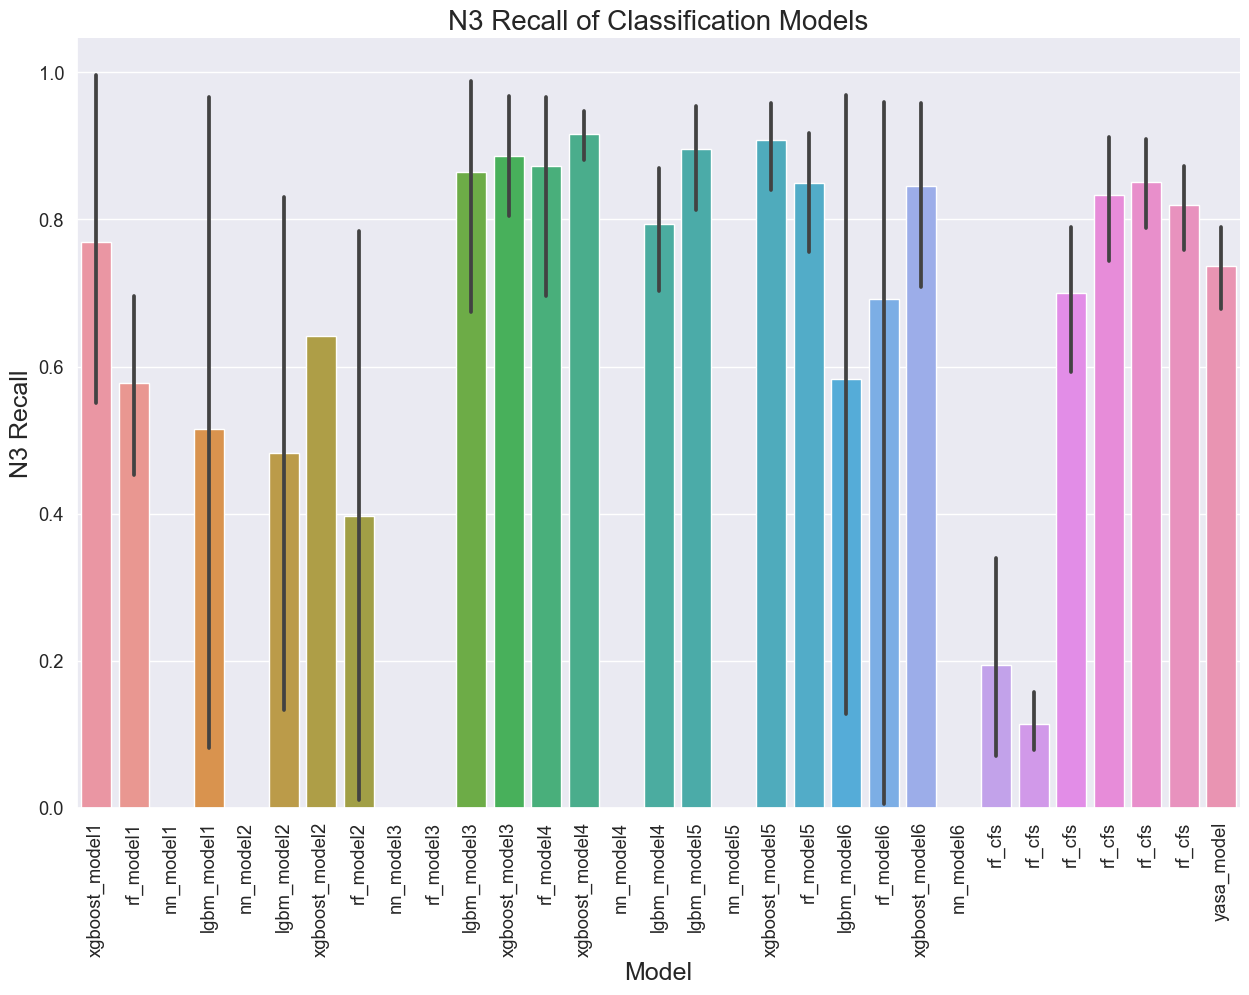

In [166]:
# N3 Recall scores
fig, ax = plt.subplots(figsize=(15, 10))
sns.barplot(x = 'model idx', y = 'N3_recall', data = df_cv_results[df_cv_results.Condition!='adaption'], ax=ax)
plt.title('N3 Recall of Classification Models', fontsize=20)
ax.set_xlabel('Model', fontsize=18)
ax.set_ylabel('N3 Recall', fontsize=18)
ax.set_xticklabels(sorted_model_names_, rotation=90)
sns.despine()
plt.savefig(new_path + 'n3_recall_scores_all_models.png')